# Statistical analyses: metacognitive sensitivity in translation production

Companion to `data_pipeline.ipynb`. Reads `BML12_2bin_trials.csv` and
`SG12_2bin_trials.csv`;
Make sure cells are run in order.


### Note on meta-d′ (exploratory only — not used in the reported analyses)

An earlier version of this analysis estimated metacognitive sensitivity with
meta-d′ (Maniscalco & Lau, 2012) alongside AUROC2. Those cells are retained
below for transparency, but none of their output appears in the paper, and
the meta-d′ values they produce should not be read as estimates.


In [41]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "--user", "metadpy"])
print("Installed. Restart the kernel before running Cell 1.")

Installed. Restart the kernel before running Cell 1.


In [42]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt


# Standalone meta-d' MLE

NRATINGS = 2   # binary Task 2: 1 = correction (low confidence), 2 = no correction (high confidence)

def trials_to_counts(stimuli, responses, confidence, nRatings):
    """Build Maniscalco & Lau nR_S1, nR_S2 count vectors."""
    stimuli    = np.asarray(stimuli, dtype=int)
    responses  = np.asarray(responses, dtype=int)
    confidence = np.asarray(confidence, dtype=int)
    nR_S1 = np.zeros(2 * nRatings)
    nR_S2 = np.zeros(2 * nRatings)
    for s, r, c in zip(stimuli, responses, confidence):
        if c < 1 or c > nRatings:
            continue
        idx = (nRatings - c) if r == 0 else (nRatings + c - 1)
        if s == 0:
            nR_S1[idx] += 1
        else:
            nR_S2[idx] += 1
    return nR_S1, nR_S2

def fit_meta_d_MLE(nR_S1, nR_S2, nRatings=2):
    """Maniscalco & Lau (2012) meta-d' MLE."""
    nR_S1 = np.asarray(nR_S1, dtype=float) + 1/(2 * nRatings)   # Hautus correction
    nR_S2 = np.asarray(nR_S2, dtype=float) + 1/(2 * nRatings)
    N_S1 = nR_S1.sum(); N_S2 = nR_S2.sum()
    FA = np.clip(nR_S1[nRatings:].sum() / N_S1, 1e-5, 1 - 1e-5)
    H  = np.clip(nR_S2[nRatings:].sum() / N_S2, 1e-5, 1 - 1e-5)
    d1 = norm.ppf(H) - norm.ppf(FA)
    c1 = -0.5 * (norm.ppf(H) + norm.ppf(FA))

    def negll(params):
        meta_d = params[0]
        if nRatings > 1:
            t2c1_R0 = c1 - np.cumsum(np.exp(params[1:nRatings]))[::-1]
            t2c1_R1 = c1 + np.cumsum(np.exp(params[nRatings:2*nRatings - 1]))
        else:
            t2c1_R0 = np.array([]); t2c1_R1 = np.array([])
        S1mu, S2mu = -meta_d / 2.0, meta_d / 2.0
        bounds = np.concatenate(([-np.inf], t2c1_R0, [c1], t2c1_R1, [np.inf]))
        p_S1 = np.diff(norm.cdf(bounds, loc=S1mu))
        p_S2 = np.diff(norm.cdf(bounds, loc=S2mu))
        p_S1_R0, p_S1_R1 = p_S1[:nRatings], p_S1[nRatings:]
        p_S2_R0, p_S2_R1 = p_S2[:nRatings], p_S2[nRatings:]
        if p_S1_R0.sum() <= 0 or p_S1_R1.sum() <= 0 or p_S2_R0.sum() <= 0 or p_S2_R1.sum() <= 0:
            return 1e10
        p_S1_R0 = p_S1_R0 / p_S1_R0.sum() * (1 - FA)
        p_S1_R1 = p_S1_R1 / p_S1_R1.sum() * FA
        p_S2_R0 = p_S2_R0 / p_S2_R0.sum() * (1 - H)
        p_S2_R1 = p_S2_R1 / p_S2_R1.sum() * H
        probs_S1 = np.clip(np.concatenate([p_S1_R0, p_S1_R1]), 1e-300, 1.0)
        probs_S2 = np.clip(np.concatenate([p_S2_R0, p_S2_R1]), 1e-300, 1.0)
        return -((nR_S1 * np.log(probs_S1)).sum() + (nR_S2 * np.log(probs_S2)).sum())

    # Parameter vector: 1 meta_d + 2*(nRatings-1) Type 2 criteria
    init = np.concatenate([[d1], np.log(np.full(max(2*(nRatings - 1), 0), 0.5))])
    best = None
    for seed in range(3):
        rng = np.random.default_rng(seed)
        x0 = init + rng.normal(0, 0.1, len(init))
        try:
            res = minimize(negll, x0, method='Nelder-Mead',
                           options={'maxiter': 10000, 'xatol': 1e-6, 'fatol': 1e-6})
            if best is None or res.fun < best.fun:
                best = res
        except Exception:
            continue
    if best is None:
        return {'d1': d1, 'meta_d': np.nan}
    return {'d1': d1, 'meta_d': float(best.x[0])}


# Per-translator meta-d' (one fit function used for both studies)

def fit_per_translator(df, task2_col, label, nRatings=NRATINGS):
    rows = []
    for part, g in df.groupby('Part'):
        nR_S1, nR_S2 = trials_to_counts(
            stimuli    = g['Task_1'].values,
            responses  = np.ones(len(g), dtype=int),
            confidence = g[task2_col].values,
            nRatings   = nRatings,
        )
        try:
            fit = fit_meta_d_MLE(nR_S1, nR_S2, nRatings=nRatings)
            metad_val = fit['meta_d']
        except Exception as e:
            print(f"  Fit failed for {part} ({label}): {e}")
            metad_val = np.nan
        rows.append({
            'Part':       part,
            'definition': label,
            'n_trials':   len(g),
            'accuracy':   g['Task_1'].mean(),
            'metad':      metad_val,
        })
    return pd.DataFrame(rows)


def group_bootstrap(ind_df, col='metad', n_boot=10000, seed=0):
    vals = ind_df[col].dropna().values
    if len(vals) == 0:
        return np.nan, np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = np.array([
        vals[rng.integers(0, len(vals), len(vals))].mean()
        for _ in range(n_boot)
    ])
    return vals.mean(), np.percentile(boots, 2.5), np.percentile(boots, 97.5), (boots > 0).mean()


# Run on both studies

def analyze_metad(csv_path, study_label):
    print(f"\n{'=' * 60}")
    print(f"  {study_label}")
    print('=' * 60)

    trials = pd.read_csv(csv_path)
    df = trials.dropna(subset=['Task_1']).copy()
    df['Task_1']       = df['Task_1'].astype(int)
    df['Task_2']       = df['Task_2'].astype(int)
    df['Task_2_Loose'] = df['Task_2_Loose'].astype(int)
    df['Task_2_Tight'] = df['Task_2_Tight'].astype(int)

    print(f"Translators: {df['Part'].nunique()}, evaluable trials: {len(df)}")
    print(f"\nFitting per-translator meta-d' for three definitions...")
    ind_medium = fit_per_translator(df, 'Task_2',       'Medium')
    ind_loose  = fit_per_translator(df, 'Task_2_Loose', 'Loose')
    ind_tight  = fit_per_translator(df, 'Task_2_Tight', 'Tight')

    group_rows = []
    for ind_df, lbl in [(ind_medium, 'Medium'), (ind_loose, 'Loose'), (ind_tight, 'Tight')]:
        mean, lo, hi, p_gt_0 = group_bootstrap(ind_df)
        group_rows.append({
            'definition':       lbl,
            'group_metad_mean': mean,
            'group_metad_lo95': lo,
            'group_metad_hi95': hi,
            'P_metad_gt_0':     p_gt_0,
        })
    group_metad = pd.DataFrame(group_rows)

    print(f"\nPER-TRANSLATOR meta-d' (Medium):")
    print(ind_medium[['Part', 'n_trials', 'accuracy', 'metad']]
          .round(3).to_string(index=False))
    print(f"\nGROUP-LEVEL meta-d':")
    print(group_metad.round(3).to_string(index=False))

    return {
        'df':           df,
        'ind_medium':   ind_medium,
        'ind_loose':    ind_loose,
        'ind_tight':    ind_tight,
        'group_metad':  group_metad,
    }

# ------------------------------------------------------------------
# Spanish and German
bml12 = analyze_metad('BML12_2bin_trials.csv', 'BML12 (Spanish)')
sg12  = analyze_metad('SG12_2bin_trials.csv',  'SG12 (German)')


bml12['ind_medium'].to_csv('BML12_individual_metad_medium.csv', index=False)
bml12['ind_loose'].to_csv ('BML12_individual_metad_loose.csv',  index=False)
bml12['ind_tight'].to_csv ('BML12_individual_metad_tight.csv',  index=False)
bml12['group_metad'].to_csv('BML12_group_metad_summary.csv',   index=False)

sg12['ind_medium'].to_csv('SG12_individual_metad_medium.csv',   index=False)
sg12['ind_loose'].to_csv ('SG12_individual_metad_loose.csv',    index=False)
sg12['ind_tight'].to_csv ('SG12_individual_metad_tight.csv',    index=False)
sg12['group_metad'].to_csv('SG12_group_metad_summary.csv',     index=False)


  BML12 (Spanish)
Translators: 32, evaluable trials: 3500

Fitting per-translator meta-d' for three definitions...

PER-TRANSLATOR meta-d' (Medium):
Part  n_trials  accuracy  metad
 P01       119     0.756  1.076
 P02        96     0.833  0.537
 P03       114     0.860  0.813
 P04       129     0.798  1.530
 P05       108     0.769  0.893
 P06        69     0.725  0.645
 P07       130     0.831  1.253
 P08        92     0.761  0.868
 P09       117     0.880  1.111
 P10       111     0.793  0.965
 P11       135     0.689  0.880
 P12        96     0.760  0.575
 P13       114     0.781  0.572
 P14       142     0.775  1.066
 P15        97     0.835  0.908
 P16       174     0.632  0.543
 P17       121     0.702  1.440
 P18       132     0.758  0.908
 P19        49     0.714  0.515
 P20       120     0.575  0.990
 P21       126     0.762  0.631
 P22       142     0.838  0.341
 P23       127     0.764  0.807
 P24        40     0.950  1.593
 P25        52     0.769  2.377
 P26       132    

In [43]:
def analyze_metad_bound(csv_path, study_label, bound='upper'):
    """Per-translator meta-d' under either the lower or upper bound."""
    if bound == 'lower':
        cols = {'Medium': 'Task_2', 'Loose': 'Task_2_Loose', 'Tight': 'Task_2_Tight'}
    elif bound == 'upper':
        cols = {'Medium': 'Task_2_Upper', 'Loose': 'Task_2_Upper_Loose', 'Tight': 'Task_2_Upper_Tight'}
    else:
        raise ValueError("bound must be 'lower' or 'upper'")

    print(f"\n{'=' * 60}")
    print(f"  {study_label} — META-D' {bound.upper()} BOUND")
    print('=' * 60)

    trials = pd.read_csv(csv_path)
    df = trials.dropna(subset=['Task_1']).copy()
    df['Task_1'] = df['Task_1'].astype(int)
    for c in cols.values():
        df[c] = df[c].astype(int)

    print(f"Translators: {df['Part'].nunique()}, evaluable trials: {len(df)}")

    ind_results = {}
    for label, col in cols.items():
        ind_results[label] = fit_per_translator(df, col, label)

    group_rows = []
    for label, ind_df in ind_results.items():
        mean, lo, hi, p_gt = group_bootstrap(ind_df, col='metad')
        group_rows.append({
            'definition': label, 'group_metad_mean': mean,
            'group_metad_lo95': lo, 'group_metad_hi95': hi, 'P_metad_gt_0': p_gt,
        })
    group_metad = pd.DataFrame(group_rows)
    

    print(f"\nGROUP META-D' ({bound} bound):")
    print(group_metad.round(3).to_string(index=False))

    return {'df': df, 'ind_medium': ind_results['Medium'],
            'ind_loose': ind_results['Loose'], 'ind_tight': ind_results['Tight'],
            'group_metad': group_metad, 'bound': bound}


# Run both bounds for both studies
bml12_meta_lower = analyze_metad_bound('BML12_2bin_trials.csv', 'BML12', bound='lower')
bml12_meta_upper = analyze_metad_bound('BML12_2bin_trials.csv', 'BML12', bound='upper')
sg12_meta_lower  = analyze_metad_bound('SG12_2bin_trials.csv',  'SG12',  bound='lower')
sg12_meta_upper  = analyze_metad_bound('SG12_2bin_trials.csv',  'SG12',  bound='upper')


  BML12 — META-D' LOWER BOUND
Translators: 32, evaluable trials: 3500

GROUP META-D' (lower bound):
definition  group_metad_mean  group_metad_lo95  group_metad_hi95  P_metad_gt_0
    Medium             1.029             0.855             1.219           1.0
     Loose             0.831             0.702             0.963           1.0
     Tight             0.962             0.702             1.221           1.0

  BML12 — META-D' UPPER BOUND
Translators: 32, evaluable trials: 3500

GROUP META-D' (upper bound):
definition  group_metad_mean  group_metad_lo95  group_metad_hi95  P_metad_gt_0
    Medium             0.985             0.849             1.128           1.0
     Loose             0.992             0.858             1.132           1.0
     Tight             0.837             0.615             1.054           1.0

  SG12 — META-D' LOWER BOUND
Translators: 24, evaluable trials: 2449

GROUP META-D' (lower bound):
definition  group_metad_mean  group_metad_lo95  group_metad_hi95  

In [44]:
from sklearn.metrics import roc_auc_score

# Type 2 AUC: encoding-free measure of confidence-accuracy coupling

def type2_auc(accuracy, confidence):
    """Single-translator Type 2 AUC."""
    if len(np.unique(accuracy)) < 2:
        return np.nan
    return roc_auc_score(accuracy, confidence)

def auc_bootstrap_ci(accuracy, confidence, n_boot=5000, seed=0):
    """95% bootstrap CI for a single translator's Type 2 AUC."""
    a = np.asarray(accuracy); c = np.asarray(confidence)
    rng = np.random.default_rng(seed)
    n = len(a)
    boots = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(a[idx])) < 2:
            continue
        boots.append(type2_auc(a[idx], c[idx]))
    if not boots:
        return np.nan, np.nan
    return np.percentile(boots, 2.5), np.percentile(boots, 97.5)

def group_bootstrap_auc(per_translator_aucs, n_boot=10000, seed=0):
    vals = per_translator_aucs.dropna().values
    if len(vals) == 0:
        return np.nan, np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = np.array([
        vals[rng.integers(0, len(vals), len(vals))].mean()
        for _ in range(n_boot)
    ])
    return vals.mean(), np.percentile(boots, 2.5), np.percentile(boots, 97.5), (boots > 0.5).mean()

def analyze_auc(df, study_label):
    print(f"\n{'=' * 60}")
    print(f"  {study_label}")
    print('=' * 60)

    # Per-translator AUC under all three definitions
    auc_records = []
    for part, g in df.groupby('Part'):
        for task2_col, lbl in [('Task_2', 'Medium'),
                               ('Task_2_Loose', 'Loose'),
                               ('Task_2_Tight', 'Tight')]:
            auc = type2_auc(g['Task_1'], g[task2_col])
            lo, hi = auc_bootstrap_ci(g['Task_1'], g[task2_col])
            auc_records.append({
                'Part':       part,
                'definition': lbl,
                'AUC':        auc,
                'AUC_lo95':   lo,
                'AUC_hi95':   hi,
            })
    auc_df = pd.DataFrame(auc_records)

    # Group-level AUC
    group_auc_rows = []
    for lbl in ['Medium', 'Loose', 'Tight']:
        sub = auc_df.loc[auc_df['definition'] == lbl, 'AUC']
        mean, lo, hi, p_gt_0_5 = group_bootstrap_auc(sub)
        group_auc_rows.append({
            'definition':      lbl,
            'group_AUC_mean':  mean,
            'group_AUC_lo95':  lo,
            'group_AUC_hi95':  hi,
            'P_AUC_gt_0.5':    p_gt_0_5,
        })
    group_auc_summary = pd.DataFrame(group_auc_rows)

    print("PER-TRANSLATOR Type 2 AUC (Medium):")
    print(auc_df[auc_df['definition'] == 'Medium']
          .drop(columns=['definition'])
          .round(3).to_string(index=False))
    print(f"\nGROUP-LEVEL Type 2 AUC:")
    print(group_auc_summary.round(3).to_string(index=False))

    return {'auc_df': auc_df, 'group_auc': group_auc_summary}


bml12_auc = analyze_auc(bml12['df'], 'BML12 (Spanish)')
sg12_auc  = analyze_auc(sg12['df'],  'SG12 (German)')

# ------------------------------------------------------------------
# Save 
bml12_auc['auc_df'].to_csv('BML12_individual_type2_auc.csv',    index=False)
bml12_auc['group_auc'].to_csv('BML12_group_type2_auc.csv',      index=False)
sg12_auc['auc_df'].to_csv('SG12_individual_type2_auc.csv',      index=False)
sg12_auc['group_auc'].to_csv('SG12_group_type2_auc.csv',        index=False)


  BML12 (Spanish)
PER-TRANSLATOR Type 2 AUC (Medium):
Part   AUC  AUC_lo95  AUC_hi95
 P01 0.546     0.495     0.609
 P02 0.519     0.474     0.594
 P03 0.547     0.478     0.642
 P04 0.673     0.578     0.768
 P05 0.590     0.506     0.682
 P06 0.565     0.475     0.673
 P07 0.582     0.507     0.672
 P08 0.554     0.486     0.636
 P09 0.562     0.485     0.667
 P10 0.586     0.506     0.679
 P11 0.549     0.501     0.603
 P12 0.515     0.481     0.568
 P13 0.538     0.478     0.614
 P14 0.591     0.521     0.668
 P15 0.550     0.481     0.645
 P16 0.543     0.498     0.592
 P17 0.591     0.527     0.661
 P18 0.574     0.508     0.646
 P19 0.521     0.461     0.610
 P20 0.574     0.517     0.635
 P21 0.534     0.485     0.599
 P22 0.518     0.467     0.588
 P23 0.551     0.491     0.622
 P24 0.500     0.500     0.500
 P25 0.667     0.538     0.813
 P26 0.581     0.491     0.688
 P27 0.554     0.481     0.639
 P28 0.509     0.456     0.599
 P29 0.583     0.528     0.646
 P30 0.643     

In [45]:
def analyze_auc_bound(df, study_label, bound='lower'):
    """Per-translator Type 2 AUC under either bound"""
    if bound == 'lower':
        cols = {'Medium': 'Task_2', 'Loose': 'Task_2_Loose', 'Tight': 'Task_2_Tight'}
    elif bound == 'upper':
        cols = {'Medium': 'Task_2_Upper', 'Loose': 'Task_2_Upper_Loose', 'Tight': 'Task_2_Upper_Tight'}
    else:
        raise ValueError("bound must be 'lower' or 'upper'")

    print(f"\n{'=' * 60}")
    print(f"  {study_label} — AUC {bound.upper()} BOUND")
    print('=' * 60)

    auc_records = []
    for part, g in df.groupby('Part'):
        for label, col in cols.items():
            auc = type2_auc(g['Task_1'], g[col])
            lo, hi = auc_bootstrap_ci(g['Task_1'], g[col])
            auc_records.append({'Part': part, 'definition': label,
                                'AUC': auc, 'AUC_lo95': lo, 'AUC_hi95': hi})
    auc_df = pd.DataFrame(auc_records)

    group_rows = []
    for label in ['Medium', 'Loose', 'Tight']:
        sub = auc_df.loc[auc_df['definition'] == label, 'AUC']
        mean, lo, hi, p_gt = group_bootstrap_auc(sub)
        group_rows.append({
            'definition': label, 'group_AUC_mean': mean,
            'group_AUC_lo95': lo, 'group_AUC_hi95': hi, 'P_AUC_gt_0.5': p_gt,
        })
    group_auc = pd.DataFrame(group_rows)

    print(f"\nGROUP AUC ({bound} bound):")
    print(group_auc.round(3).to_string(index=False))

    return {'auc_df': auc_df, 'group_auc': group_auc, 'bound': bound}


bml12_auc_lower = analyze_auc_bound(bml12_meta_lower['df'], 'BML12', bound='lower')
bml12_auc_upper = analyze_auc_bound(bml12_meta_upper['df'], 'BML12', bound='upper')
sg12_auc_lower  = analyze_auc_bound(sg12_meta_lower['df'],  'SG12',  bound='lower')
sg12_auc_upper  = analyze_auc_bound(sg12_meta_upper['df'],  'SG12',  bound='upper')


  BML12 — AUC LOWER BOUND

GROUP AUC (lower bound):
definition  group_AUC_mean  group_AUC_lo95  group_AUC_hi95  P_AUC_gt_0.5
    Medium           0.567           0.553           0.582           1.0
     Loose           0.630           0.610           0.651           1.0
     Tight           0.526           0.516           0.537           1.0

  BML12 — AUC UPPER BOUND

GROUP AUC (upper bound):
definition  group_AUC_mean  group_AUC_lo95  group_AUC_hi95  P_AUC_gt_0.5
    Medium           0.618           0.594           0.644           1.0
     Loose           0.680           0.657           0.704           1.0
     Tight           0.562           0.538           0.588           1.0

  SG12 — AUC LOWER BOUND

GROUP AUC (lower bound):
definition  group_AUC_mean  group_AUC_lo95  group_AUC_hi95  P_AUC_gt_0.5
    Medium           0.539           0.526           0.551           1.0
     Loose           0.596           0.567           0.625           1.0
     Tight           0.516           0.

In [46]:

# Table— joint distribution of Type 1 and Type 2 outcomes, by bound.
# Table — distribution of per-participant AUROC2, by bound.
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

TRIAL_FILES = [('BML12 (Spanish)', 'BML12_2bin_trials.csv'),
               ('SG12 (German)',   'SG12_2bin_trials.csv')]
BOUNDS = [('Lower bound', 'Task_2'), ('Upper bound', 'Task_2_Upper')]


def _gradeable(path):
    d = pd.read_csv(path).dropna(subset=['Task_1']).copy()
    d['Task_1'] = d['Task_1'].astype(int)
    return d


def contingency(df, col):
    """rows Task_1 in (0, 1), columns Bin 1 / Bin 2."""
    ct = (pd.crosstab(df['Task_1'], df[col])
            .reindex(index=[0, 1], columns=[1, 2])
            .fillna(0).astype(int))
    ct.index = ['Task 1 = 0 (unstable)', 'Task 1 = 1 (stable)']
    ct.columns = ['Bin 1 (reformulated)', 'Bin 2 (not reformulated)']
    ct['Total'] = ct.sum(axis=1)
    ct.loc['Total'] = ct.sum(axis=0)
    return ct


def per_participant_auroc2(df, col):
    """AUROC2 per participant; NaN where Task 1 is constant."""
    return pd.Series({
        p: (roc_auc_score(g['Task_1'], g[col]) if g['Task_1'].nunique() == 2 else np.nan)
        for p, g in df.groupby('Part')
    })


# ------------------------------------------------------------------
# Table 2
print('=' * 78)
print('  TABLE 2 — Joint distribution of Type 1 and Type 2 outcomes')
print('=' * 78)

table2_rows = []
for study, path in TRIAL_FILES:
    df = _gradeable(path)
    print(f"\n{study}, n = {len(df):,}")
    for bound_label, col in BOUNDS:
        ct = contingency(df, col)
        print(f"\n  {bound_label}")
        print(ct.to_string().replace('\n', '\n  '))
        for row in ct.index[:-1]:
            table2_rows.append({
                'study': study, 'bound': bound_label, 'task1': row,
                'bin1': ct.loc[row, 'Bin 1 (reformulated)'],
                'bin2': ct.loc[row, 'Bin 2 (not reformulated)'],
                'total': ct.loc[row, 'Total'],
            })

        p_bin2_unstable = ct.loc['Task 1 = 0 (unstable)', 'Bin 2 (not reformulated)'] / ct.loc['Task 1 = 0 (unstable)', 'Total']
        p_bin2_stable   = ct.loc['Task 1 = 1 (stable)',   'Bin 2 (not reformulated)'] / ct.loc['Task 1 = 1 (stable)',   'Total']
        print(f"\n    P(Bin 2 | unstable) = {p_bin2_unstable:.3f}   "
              f"P(Bin 2 | stable) = {p_bin2_stable:.3f}   "
              f"AUROC2 (pooled trials) = {0.5 * (p_bin2_stable + 1 - p_bin2_unstable):.3f}")

pd.DataFrame(table2_rows).to_csv('table2_contingency.csv', index=False)

# ------------------------------------------------------------------
# Table 4
print('\n' + '=' * 78)
print('  TABLE 4 — Distribution of per-participant AUROC2')
print('=' * 78)

table4 = {}
for study, path in TRIAL_FILES:
    df = _gradeable(path)
    short = study.split()[0]
    for bound_label, col in BOUNDS:
        v = per_participant_auroc2(df, col).dropna()
        table4[f"{short} {bound_label.split()[0].lower()}"] = {
            'M':               v.mean(),
            'SD':              v.std(ddof=1),
            'Minimum':         v.min(),
            '25th percentile': v.quantile(0.25),
            'Median':          v.median(),
            '75th percentile': v.quantile(0.75),
            'Maximum':         v.max(),
            'Range':           v.max() - v.min(),
            'Above 0.5':       f"{int((v > 0.5).sum())} / {len(v)}",
        }

table4 = pd.DataFrame(table4)
numeric = table4.index != 'Above 0.5'
table4.loc[numeric] = table4.loc[numeric].astype(float).round(3)
print()
print(table4.to_string())
table4.to_csv('table4_auroc2_distribution.csv')

print("\nSaved table2_contingency.csv and table4_auroc2_distribution.csv")

  TABLE 2 — Joint distribution of Type 1 and Type 2 outcomes

BML12 (Spanish), n = 3,500

  Lower bound
                       Bin 1 (reformulated)  Bin 2 (not reformulated)  Total
  Task 1 = 0 (unstable)                   132                       663    795
  Task 1 = 1 (stable)                      85                      2620   2705
  Total                                   217                      3283   3500

    P(Bin 2 | unstable) = 0.834   P(Bin 2 | stable) = 0.969   AUROC2 (pooled trials) = 0.567

  Upper bound
                       Bin 1 (reformulated)  Bin 2 (not reformulated)  Total
  Task 1 = 0 (unstable)                   267                       528    795
  Task 1 = 1 (stable)                     230                      2475   2705
  Total                                   497                      3003   3500

    P(Bin 2 | unstable) = 0.664   P(Bin 2 | stable) = 0.915   AUROC2 (pooled trials) = 0.625

SG12 (German), n = 2,449

  Lower bound
                       B

In [47]:
# Robustness

def _medium_auc(auc_obj):
    d = auc_obj['auc_df']
    return d[d['definition'] == 'Medium'].set_index('Part')['AUC']

def _fmt(series):
    m, lo, hi, p = group_bootstrap_auc(series)
    return f"{m:.3f} [{lo:.3f}, {hi:.3f}]  P(>0.5)={p:.3f}"

bl = _medium_auc(bml12_auc_lower);  bu = _medium_auc(bml12_auc_upper)
sl = _medium_auc(sg12_auc_lower);   su = _medium_auc(sg12_auc_upper)

# (a) Excluding P24 
print("="*70); print("3.6  Excluding BML12 P24"); print("="*70)
print(f"BML12  lower: {_fmt(bl.drop('P24'))}")
print(f"BML12  upper: {_fmt(bu.drop('P24'))}")
print(f"Pooled lower: {_fmt(pd.concat([bl.drop('P24'), sl]))}")
print(f"Pooled upper: {_fmt(pd.concat([bu.drop('P24'), su]))}")

# (b) Restricting to participants with >= 20 unstable (Task_1 == 0) trials
print("\n" + "="*70); print("3.6  >= 20 unstable trials"); print("="*70)
for lbl, df_full, low, up in [('BML12', bml12['df'], bl, bu),
                              ('SG12',  sg12['df'],  sl, su)]:
    n_unstable = df_full[df_full['Task_1'] == 0].groupby('Part').size()
    keep = n_unstable[n_unstable >= 20].index
    print(f"{lbl} (n={len(keep)}): lower {_fmt(low[low.index.isin(keep)])}")
    print(f"{' '*(len(lbl)+9)}upper {_fmt(up[up.index.isin(keep)])}")

3.6  Excluding BML12 P24
BML12  lower: 0.569 [0.555, 0.585]  P(>0.5)=1.000
BML12  upper: 0.622 [0.599, 0.646]  P(>0.5)=1.000
Pooled lower: 0.556 [0.546, 0.567]  P(>0.5)=1.000
Pooled upper: 0.623 [0.605, 0.643]  P(>0.5)=1.000

3.6  >= 20 unstable trials
BML12 (n=20): lower 0.567 [0.553, 0.583]  P(>0.5)=1.000
              upper 0.618 [0.593, 0.642]  P(>0.5)=1.000
SG12 (n=12): lower 0.548 [0.530, 0.566]  P(>0.5)=1.000
             upper 0.669 [0.626, 0.713]  P(>0.5)=1.000


In [48]:
def compare_translator_bounds(meta_lower, meta_upper, auc_lower, auc_upper, study_label):
    """For each translator, show their lower-bound and upper-bound meta-d' and AUC."""
    # Lower bound per-translator (Medium)
    lower = meta_lower['ind_medium'][['Part', 'accuracy', 'metad']].merge(
        auc_lower['auc_df'][auc_lower['auc_df']['definition'] == 'Medium'][['Part', 'AUC']],
        on='Part'
    )
    lower.columns = ['Part', 'accuracy', 'metad_lower', 'AUC_lower']

    # Upper bound per-translator (Medium)
    upper = meta_upper['ind_medium'][['Part', 'metad']].merge(
        auc_upper['auc_df'][auc_upper['auc_df']['definition'] == 'Medium'][['Part', 'AUC']],
        on='Part'
    )
    upper.columns = ['Part', 'metad_upper', 'AUC_upper']

    combined = lower.merge(upper, on='Part')
    combined['metad_change'] = combined['metad_upper'] - combined['metad_lower']
    combined['AUC_change']   = combined['AUC_upper']   - combined['AUC_lower']

    print(f"\n{'=' * 90}")
    print(f"  {study_label} — Per-translator lower vs upper bound (Medium)")
    print('=' * 90)
    print(combined.round(3).to_string(index=False))
    print(f"\nMean change in meta-d': {combined['metad_change'].mean():+.3f}")
    print(f"Mean change in AUC:     {combined['AUC_change'].mean():+.3f}")
    print(f"\nTranslators whose AUC increased:  "
          f"{(combined['AUC_change'] > 0).sum()} / {len(combined)}")
    print(f"Translators whose meta-d' increased: "
          f"{(combined['metad_change'] > 0).sum()} / {len(combined)}")

    return combined


bml12_per_translator = compare_translator_bounds(
    bml12_meta_lower, bml12_meta_upper, bml12_auc_lower, bml12_auc_upper, 'BML12 (Spanish)'
)
sg12_per_translator = compare_translator_bounds(
    sg12_meta_lower, sg12_meta_upper, sg12_auc_lower, sg12_auc_upper, 'SG12 (German)'
)

# Save
bml12_per_translator.to_csv('BML12_per_translator_both_bounds.csv', index=False)
sg12_per_translator.to_csv('SG12_per_translator_both_bounds.csv', index=False)


  BML12 (Spanish) — Per-translator lower vs upper bound (Medium)
Part  accuracy  metad_lower  AUC_lower  metad_upper  AUC_upper  metad_change  AUC_change
 P01     0.756        1.076      0.546        0.593      0.553        -0.483       0.007
 P02     0.833        0.537      0.519        0.735      0.581         0.198       0.062
 P03     0.860        0.813      0.547        1.500      0.667         0.687       0.120
 P04     0.798        1.530      0.673        1.280      0.716        -0.250       0.043
 P05     0.769        0.893      0.590        1.044      0.684         0.151       0.094
 P06     0.725        0.645      0.565        0.734      0.598         0.088       0.033
 P07     0.831        1.253      0.582        0.617      0.567        -0.636      -0.014
 P08     0.761        0.868      0.554        0.908      0.601         0.040       0.047
 P09     0.880        1.111      0.562        1.060      0.588        -0.050       0.026
 P10     0.793        0.965      0.586      

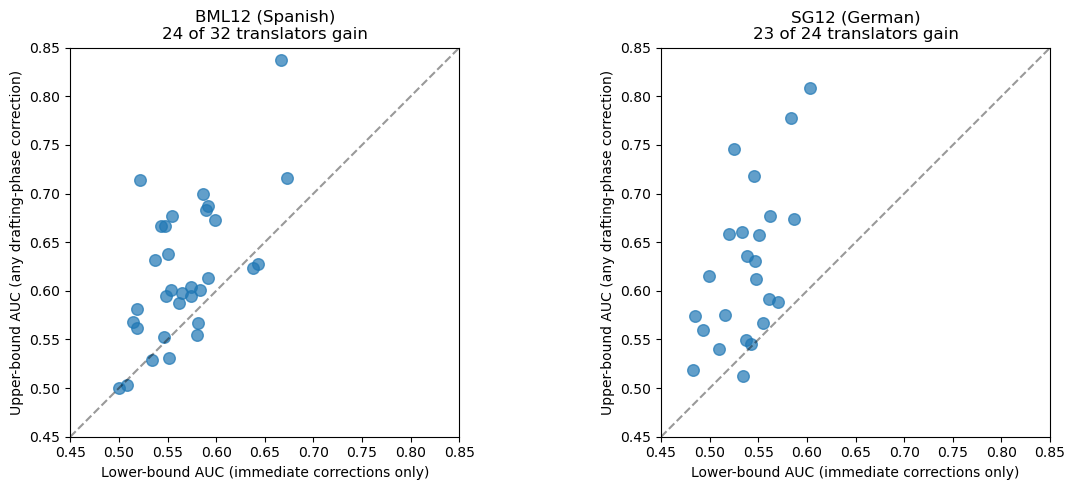

In [49]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, title in [
    (axes[0], bml12_per_translator, 'BML12 (Spanish)'),
    (axes[1], sg12_per_translator,  'SG12 (German)'),
]:
    ax.scatter(df['AUC_lower'], df['AUC_upper'], s=70, alpha=0.7)
    ax.plot([0.45, 0.85], [0.45, 0.85], 'k--', alpha=0.4, label='lower = upper')
    ax.set_xlabel('Lower-bound AUC (immediate corrections only)')
    ax.set_ylabel('Upper-bound AUC (any drafting-phase correction)')
    ax.set_title(f"{title}\n{(df['AUC_upper'] > df['AUC_lower']).sum()} of {len(df)} translators gain")
    ax.set_aspect('equal')
    ax.set_xlim(0.45, 0.85); ax.set_ylim(0.45, 0.85)

plt.tight_layout()
plt.savefig('per_translator_bounds_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [50]:
from scipy.stats import spearmanr

def corr_with_ci(x, y, n_boot=10000, seed=0):
    x = np.asarray(x); y = np.asarray(y)
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    if len(x) < 3:
        return np.nan, np.nan, np.nan, np.nan
    rho, p = spearmanr(x, y)
    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(x), len(x))
        if len(np.unique(x[idx])) < 2 or len(np.unique(y[idx])) < 2:
            continue
        r, _ = spearmanr(x[idx], y[idx])
        if not np.isnan(r):
            boots.append(r)
    return rho, p, np.percentile(boots, 2.5), np.percentile(boots, 97.5)


def analyze_dissociation(metad_result, auc_result, study_label):
    print(f"\n{'=' * 60}")
    print(f"  {study_label} — Dissociation")
    print('=' * 60)

    # Merge per-translator accuracy, meta-d', and AUC (Medium)
    ind = metad_result['ind_medium'][['Part', 'accuracy', 'metad']].copy()
    auc_med = auc_result['auc_df'].loc[
        auc_result['auc_df']['definition'] == 'Medium', ['Part', 'AUC']
    ]
    ind = ind.merge(auc_med, on='Part')

    print("Per-translator summary (Medium):")
    print(ind.round(3).to_string(index=False))

    # Three correlations
    corr_rows = []
    for x_col, y_col, label in [
        ('accuracy', 'metad', 'Accuracy <-> meta-d'),
        ('accuracy', 'AUC',   'Accuracy <-> Type 2 AUC'),
        ('metad',    'AUC',   'meta-d <-> Type 2 AUC (convergent validity)'),
    ]:
        rho, p, lo, hi = corr_with_ci(ind[x_col], ind[y_col])
        print(f"\n{label}")
        print(f"  Spearman rho = {rho:+.3f}, p = {p:.3f}, 95% bootstrap CI = [{lo:+.3f}, {hi:+.3f}]")
        corr_rows.append({
            'comparison': label, 'rho': rho, 'p_value': p,
            'rho_lo95': lo, 'rho_hi95': hi,
        })

    return {'ind_summary': ind, 'correlations': pd.DataFrame(corr_rows)}


bml12_dissoc = analyze_dissociation(bml12, bml12_auc, 'BML12 (Spanish)')
sg12_dissoc  = analyze_dissociation(sg12,  sg12_auc,  'SG12 (German)')

# Save
bml12_dissoc['ind_summary'].to_csv('BML12_per_translator_summary.csv',  index=False)
bml12_dissoc['correlations'].to_csv('BML12_dissociation_correlations.csv', index=False)
sg12_dissoc['ind_summary'].to_csv('SG12_per_translator_summary.csv',    index=False)
sg12_dissoc['correlations'].to_csv('SG12_dissociation_correlations.csv',   index=False)


  BML12 (Spanish) — Dissociation
Per-translator summary (Medium):
Part  accuracy  metad   AUC
 P01     0.756  1.076 0.546
 P02     0.833  0.537 0.519
 P03     0.860  0.813 0.547
 P04     0.798  1.530 0.673
 P05     0.769  0.893 0.590
 P06     0.725  0.645 0.565
 P07     0.831  1.253 0.582
 P08     0.761  0.868 0.554
 P09     0.880  1.111 0.562
 P10     0.793  0.965 0.586
 P11     0.689  0.880 0.549
 P12     0.760  0.575 0.515
 P13     0.781  0.572 0.538
 P14     0.775  1.066 0.591
 P15     0.835  0.908 0.550
 P16     0.632  0.543 0.543
 P17     0.702  1.440 0.591
 P18     0.758  0.908 0.574
 P19     0.714  0.515 0.521
 P20     0.575  0.990 0.574
 P21     0.762  0.631 0.534
 P22     0.838  0.341 0.518
 P23     0.764  0.807 0.551
 P24     0.950  1.593 0.500
 P25     0.769  2.377 0.667
 P26     0.879  1.150 0.581
 P27     0.782  0.650 0.554
 P28     0.868  0.240 0.509
 P29     0.632  1.936 0.583
 P30     0.876  2.543 0.643
 P31     0.752  1.318 0.599
 P32     0.795  1.242 0.638

Accuracy

In [51]:
def corr_with_ci(x, y, n_boot=10000, seed=0):
    x = np.asarray(x); y = np.asarray(y)
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    if len(x) < 3:
        return np.nan, np.nan, np.nan, np.nan
    rho, p = spearmanr(x, y)
    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(x), len(x))
        if len(np.unique(x[idx])) < 2 or len(np.unique(y[idx])) < 2:
            continue
        r, _ = spearmanr(x[idx], y[idx])
        if not np.isnan(r):
            boots.append(r)
    return rho, p, np.percentile(boots, 2.5), np.percentile(boots, 97.5)


def analyze_dissociation(metad_result, auc_result, study_label):
    """Per-study dissociation under whichever bound the inputs were computed for."""
    bound = metad_result.get('bound', 'unknown')
    print(f"\n{'=' * 60}")
    print(f"  {study_label} — Dissociation ({bound} bound)")
    print('=' * 60)

    ind = metad_result['ind_medium'][['Part', 'accuracy', 'metad']].copy()
    auc_med = auc_result['auc_df'].loc[
        auc_result['auc_df']['definition'] == 'Medium', ['Part', 'AUC']
    ]
    ind = ind.merge(auc_med, on='Part')

    print(f"Per-translator summary (Medium, {bound} bound):")
    print(ind.round(3).to_string(index=False))

    corr_rows = []
    for x_col, y_col, label in [
        ('accuracy', 'metad', 'Accuracy <-> meta-d'),
        ('accuracy', 'AUC',   'Accuracy <-> Type 2 AUC'),
        ('metad',    'AUC',   'meta-d <-> Type 2 AUC (convergent validity)'),
    ]:
        rho, p, lo, hi = corr_with_ci(ind[x_col], ind[y_col])
        print(f"\n{label}")
        print(f"  Spearman rho = {rho:+.3f}, p = {p:.3f}, 95% bootstrap CI = [{lo:+.3f}, {hi:+.3f}]")
        corr_rows.append({
            'bound': bound, 'comparison': label, 'rho': rho, 'p_value': p,
            'rho_lo95': lo, 'rho_hi95': hi,
        })
    return {'ind_summary': ind, 'correlations': pd.DataFrame(corr_rows)}


# ------------------------------------------------------------------
# Run for both studies and bounds
bml12_dissoc_lower = analyze_dissociation(bml12_meta_lower, bml12_auc_lower, 'BML12 (Spanish)')
bml12_dissoc_upper = analyze_dissociation(bml12_meta_upper, bml12_auc_upper, 'BML12 (Spanish)')
sg12_dissoc_lower  = analyze_dissociation(sg12_meta_lower,  sg12_auc_lower,  'SG12 (German)')
sg12_dissoc_upper  = analyze_dissociation(sg12_meta_upper,  sg12_auc_upper,  'SG12 (German)')

# ------------------------------------------------------------------
# Save
for result, study, bound in [
    (bml12_dissoc_lower, 'BML12', 'lower'),
    (bml12_dissoc_upper, 'BML12', 'upper'),
    (sg12_dissoc_lower,  'SG12',  'lower'),
    (sg12_dissoc_upper,  'SG12',  'upper'),
]:
    result['ind_summary'].to_csv(f'{study}_per_translator_summary_{bound}.csv', index=False)
    result['correlations'].to_csv(f'{study}_dissociation_correlations_{bound}.csv', index=False)

# ------------------------------------------------------------------
# Side-by-side comparison of dissociation under both bounds
print("\n" + "=" * 90)
print("DISSOCIATION COMPARISON: lower vs upper bound")
print("=" * 90)

for study, lower_res, upper_res in [
    ('BML12', bml12_dissoc_lower, bml12_dissoc_upper),
    ('SG12',  sg12_dissoc_lower,  sg12_dissoc_upper),
]:
    print(f"\n{study}:")
    print(f"  {'Test':<42}{'Lower bound':<28}{'Upper bound':<28}")
    print('  ' + '-' * 96)
    for _, lo_row in lower_res['correlations'].iterrows():
        comp = lo_row['comparison']
        up_row = upper_res['correlations'][upper_res['correlations']['comparison'] == comp].iloc[0]
        lo_str = f"rho={lo_row['rho']:+.2f}, p={lo_row['p_value']:.3f}"
        up_str = f"rho={up_row['rho']:+.2f}, p={up_row['p_value']:.3f}"
        print(f"  {comp:<42}{lo_str:<28}{up_str:<28}")


  BML12 (Spanish) — Dissociation (lower bound)
Per-translator summary (Medium, lower bound):
Part  accuracy  metad   AUC
 P01     0.756  1.076 0.546
 P02     0.833  0.537 0.519
 P03     0.860  0.813 0.547
 P04     0.798  1.530 0.673
 P05     0.769  0.893 0.590
 P06     0.725  0.645 0.565
 P07     0.831  1.253 0.582
 P08     0.761  0.868 0.554
 P09     0.880  1.111 0.562
 P10     0.793  0.965 0.586
 P11     0.689  0.880 0.549
 P12     0.760  0.575 0.515
 P13     0.781  0.572 0.538
 P14     0.775  1.066 0.591
 P15     0.835  0.908 0.550
 P16     0.632  0.543 0.543
 P17     0.702  1.440 0.591
 P18     0.758  0.908 0.574
 P19     0.714  0.515 0.521
 P20     0.575  0.990 0.574
 P21     0.762  0.631 0.534
 P22     0.838  0.341 0.518
 P23     0.764  0.807 0.551
 P24     0.950  1.593 0.500
 P25     0.769  2.377 0.667
 P26     0.879  1.150 0.581
 P27     0.782  0.650 0.554
 P28     0.868  0.240 0.509
 P29     0.632  1.936 0.583
 P30     0.876  2.543 0.643
 P31     0.752  1.318 0.599
 P32     0

In [52]:
# For SG12 upper bound: influence of high-gain translators
sg12_summary_upper = sg12_dissoc_upper['ind_summary'].copy()
# Add gain
sg12_per = sg12_per_translator.set_index('Part')
sg12_summary_upper['AUC_gain'] = sg12_summary_upper['Part'].map(sg12_per['AUC_change'])

# Sort by gain
print(sg12_summary_upper.sort_values('AUC_gain', ascending=False).round(3).to_string(index=False))

# Re-compute correlation excluding top-2 gainers
trimmed = sg12_summary_upper.nsmallest(22, 'AUC_gain') 
from scipy.stats import spearmanr
print(f"\nWith top-2 gainers removed (N={len(trimmed)}):")
print(f"  Accuracy ↔ AUC ρ = {spearmanr(trimmed['accuracy'], trimmed['AUC'])[0]:+.3f}")

Part  accuracy  metad   AUC  AUC_gain
 P21     0.779  1.663 0.746     0.221
 P23     0.805  1.875 0.809     0.206
 P22     0.546  1.567 0.778     0.194
 P12     0.644  1.251 0.719     0.173
 P15     0.742  1.011 0.658     0.138
 P09     0.832  1.272 0.661     0.128
 P05     0.741  0.765 0.615     0.117
 P04     0.765  1.173 0.677     0.115
 P20     0.837  1.294 0.657     0.107
 P10     0.811  1.068 0.635     0.097
 P08     0.907  0.896 0.574     0.090
 P02     0.796  1.442 0.674     0.087
 P17     0.753  0.774 0.630     0.084
 P07     0.544  0.396 0.560     0.067
 P16     0.837  1.001 0.613     0.065
 P13     0.871  0.739 0.576     0.060
 P11     0.877  0.316 0.519     0.036
 P01     0.702  0.743 0.592     0.031
 P24     0.855  0.407 0.541     0.031
 P14     0.856  0.673 0.589     0.019
 P19     0.807  0.760 0.567     0.012
 P03     0.779  0.609 0.549     0.011
 P06     0.768  0.389 0.546     0.004
 P18     0.891  0.275 0.512    -0.022

With top-2 gainers removed (N=22):
  Accuracy ↔ A

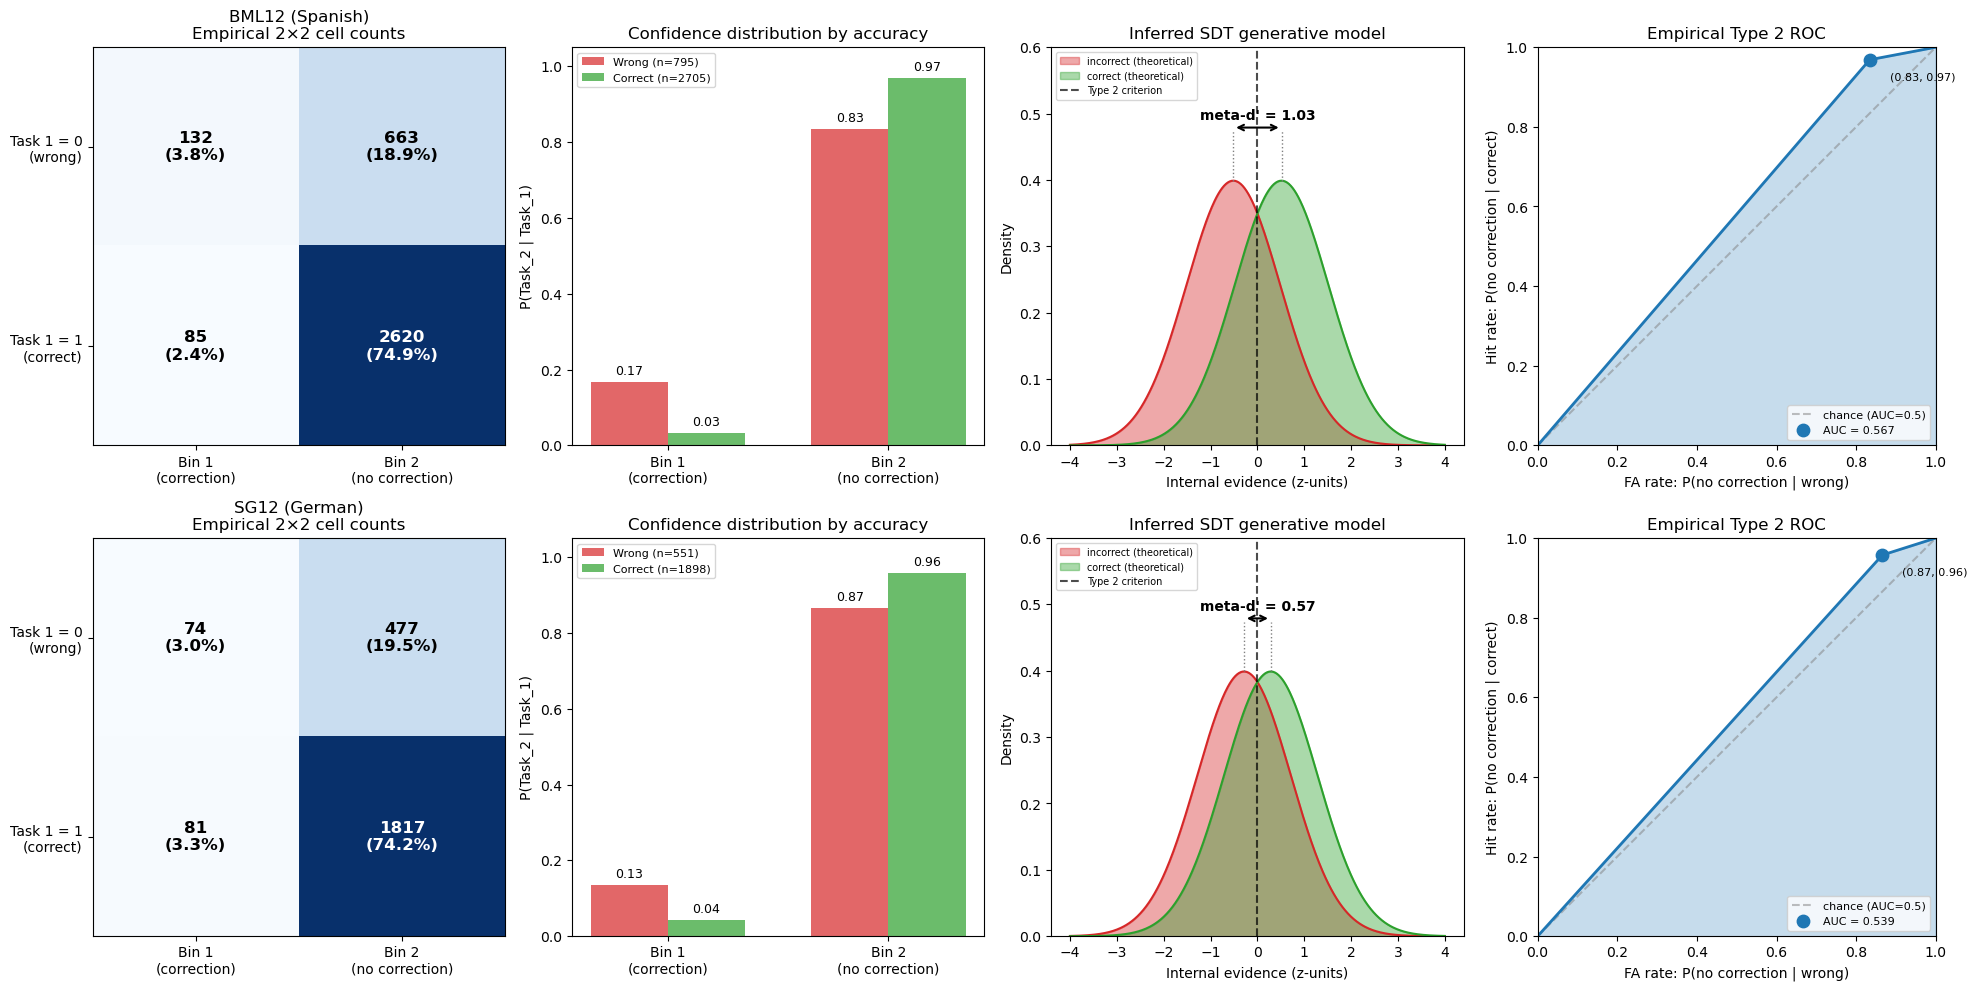

Saved sdt_empirical_and_model.png


In [53]:
# contains superseded exploratory meta-d' analysis

from scipy.stats import norm


def plot_study_full(df, group_metad, group_auc, study_label, axes):
    """
    Four panels per study:
      [0] Empirical 2x2 cell counts (raw contingency table)
      [1] Conditional confidence distributions (P(Task_2 | Task_1))
      [2] Inferred SDT Gaussian model with meta-d' arrow
      [3] Type 2 ROC point and AUC area
    axes: array of 4 matplotlib axes
    """
    metad = group_metad.loc[group_metad['definition'] == 'Medium', 'group_metad_mean'].iloc[0]
    auc   = group_auc.loc[group_auc['definition']   == 'Medium', 'group_AUC_mean'].iloc[0]

   
    # PANEL 0 — Empirical 2×2 contingency table (raw counts)

    ax = axes[0]
    ct = pd.crosstab(df['Task_1'], df['Task_2'])
    # Ensure both Task_1 levels (0, 1) and both Task_2 levels (1, 2) are present
    for t1 in [0, 1]:
        if t1 not in ct.index:
            ct.loc[t1] = 0
    for t2 in [1, 2]:
        if t2 not in ct.columns:
            ct[t2] = 0
    ct = ct.loc[[0, 1], [1, 2]]

    im = ax.imshow(ct.values, cmap='Blues', aspect='auto')
    for i in range(2):
        for j in range(2):
            n = ct.values[i, j]
            pct = n / ct.values.sum() * 100
            color = 'white' if n > ct.values.max() / 2 else 'black'
            ax.text(j, i, f"{n}\n({pct:.1f}%)", ha='center', va='center',
                    fontsize=12, fontweight='bold', color=color)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Bin 1\n(correction)', 'Bin 2\n(no correction)'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Task 1 = 0\n(wrong)', 'Task 1 = 1\n(correct)'])
    ax.set_title(f"{study_label}\nEmpirical 2×2 cell counts")


    # PANEL 1 — Conditional confidence distributions P(Task_2 | Task_1)

    ax = axes[1]
    # P(low conf = Bin 1 | wrong) and P(low conf = Bin 1 | correct)
    p_b1_wrong   = ct.loc[0, 1] / ct.loc[0].sum() if ct.loc[0].sum() > 0 else 0
    p_b2_wrong   = ct.loc[0, 2] / ct.loc[0].sum() if ct.loc[0].sum() > 0 else 0
    p_b1_correct = ct.loc[1, 1] / ct.loc[1].sum() if ct.loc[1].sum() > 0 else 0
    p_b2_correct = ct.loc[1, 2] / ct.loc[1].sum() if ct.loc[1].sum() > 0 else 0

    x_pos = np.arange(2)
    width = 0.35
    ax.bar(x_pos - width/2, [p_b1_wrong, p_b2_wrong], width,
           label=f'Wrong (n={int(ct.loc[0].sum())})', color='C3', alpha=0.7)
    ax.bar(x_pos + width/2, [p_b1_correct, p_b2_correct], width,
           label=f'Correct (n={int(ct.loc[1].sum())})', color='C2', alpha=0.7)

    for x, y in zip(x_pos - width/2, [p_b1_wrong, p_b2_wrong]):
        ax.text(x, y + 0.02, f'{y:.2f}', ha='center', fontsize=9)
    for x, y in zip(x_pos + width/2, [p_b1_correct, p_b2_correct]):
        ax.text(x, y + 0.02, f'{y:.2f}', ha='center', fontsize=9)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Bin 1\n(correction)', 'Bin 2\n(no correction)'])
    ax.set_ylabel('P(Task_2 | Task_1)')
    ax.set_title('Confidence distribution by accuracy')
    ax.set_ylim(0, 1.05)
    ax.legend(loc='upper left', fontsize=8)


    # PANEL 2 — Inferred SDT Gaussian model with meta-d' arrow

    ax = axes[2]
    x = np.linspace(-4, 4, 400)
    S1mu, S2mu = -metad / 2, metad / 2
    peak_y = norm.pdf(0, 0, 1)

    ax.fill_between(x, norm.pdf(x, S1mu, 1), alpha=0.4, color='C3', label='incorrect (theoretical)')
    ax.fill_between(x, norm.pdf(x, S2mu, 1), alpha=0.4, color='C2', label='correct (theoretical)')
    ax.plot(x, norm.pdf(x, S1mu, 1), color='C3', lw=1.5)
    ax.plot(x, norm.pdf(x, S2mu, 1), color='C2', lw=1.5)
    ax.axvline(0, color='black', ls='--', lw=1.5, alpha=0.7, label='Type 2 criterion')

    y_arrow = peak_y + 0.08
    ax.plot([S1mu, S1mu], [peak_y, y_arrow - 0.005], color='gray', ls=':', lw=1)
    ax.plot([S2mu, S2mu], [peak_y, y_arrow - 0.005], color='gray', ls=':', lw=1)
    ax.annotate('', xy=(S2mu, y_arrow), xytext=(S1mu, y_arrow),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax.text(0, y_arrow + 0.012, f"meta-d' = {metad:.2f}",
            ha='center', fontsize=10, fontweight='bold')

    ax.set_xlabel('Internal evidence (z-units)')
    ax.set_ylabel('Density')
    ax.set_title('Inferred SDT generative model')
    ax.set_ylim(0, 0.6)
    ax.legend(loc='upper left', fontsize=7)


    # PANEL 3 — Type 2 ROC point and AUC area
  
    ax = axes[3]
    # Empirical operating point: FA = P(Bin 2 | wrong), Hit = P(Bin 2 | correct)
    fa_pt  = p_b2_wrong
    hit_pt = p_b2_correct
    ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5, label='chance (AUC=0.5)')
    ax.fill_between([0, fa_pt, 1], [0, hit_pt, 1], alpha=0.25, color='C0')
    ax.plot([0, fa_pt, 1], [0, hit_pt, 1], color='C0', lw=2)
    ax.scatter([fa_pt], [hit_pt], color='C0', s=80, zorder=5,
               label=f'AUC = {auc:.3f}')
    ax.annotate(f'({fa_pt:.2f}, {hit_pt:.2f})', xy=(fa_pt, hit_pt),
                xytext=(fa_pt + 0.05, hit_pt - 0.05), fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('FA rate: P(no correction | wrong)')
    ax.set_ylabel('Hit rate: P(no correction | correct)')
    ax.set_title('Empirical Type 2 ROC')
    ax.legend(loc='lower right', fontsize=8)
    ax.set_aspect('equal')

# ------------------------------------------------------------------
# Make figure
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

plot_study_full(bml12['df'], bml12['group_metad'], bml12_auc['group_auc'],
                'BML12 (Spanish)', axes[0])
plot_study_full(sg12['df'],  sg12['group_metad'],  sg12_auc['group_auc'],
                'SG12 (German)',   axes[1])

plt.tight_layout()
plt.savefig('sdt_empirical_and_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved sdt_empirical_and_model.png")

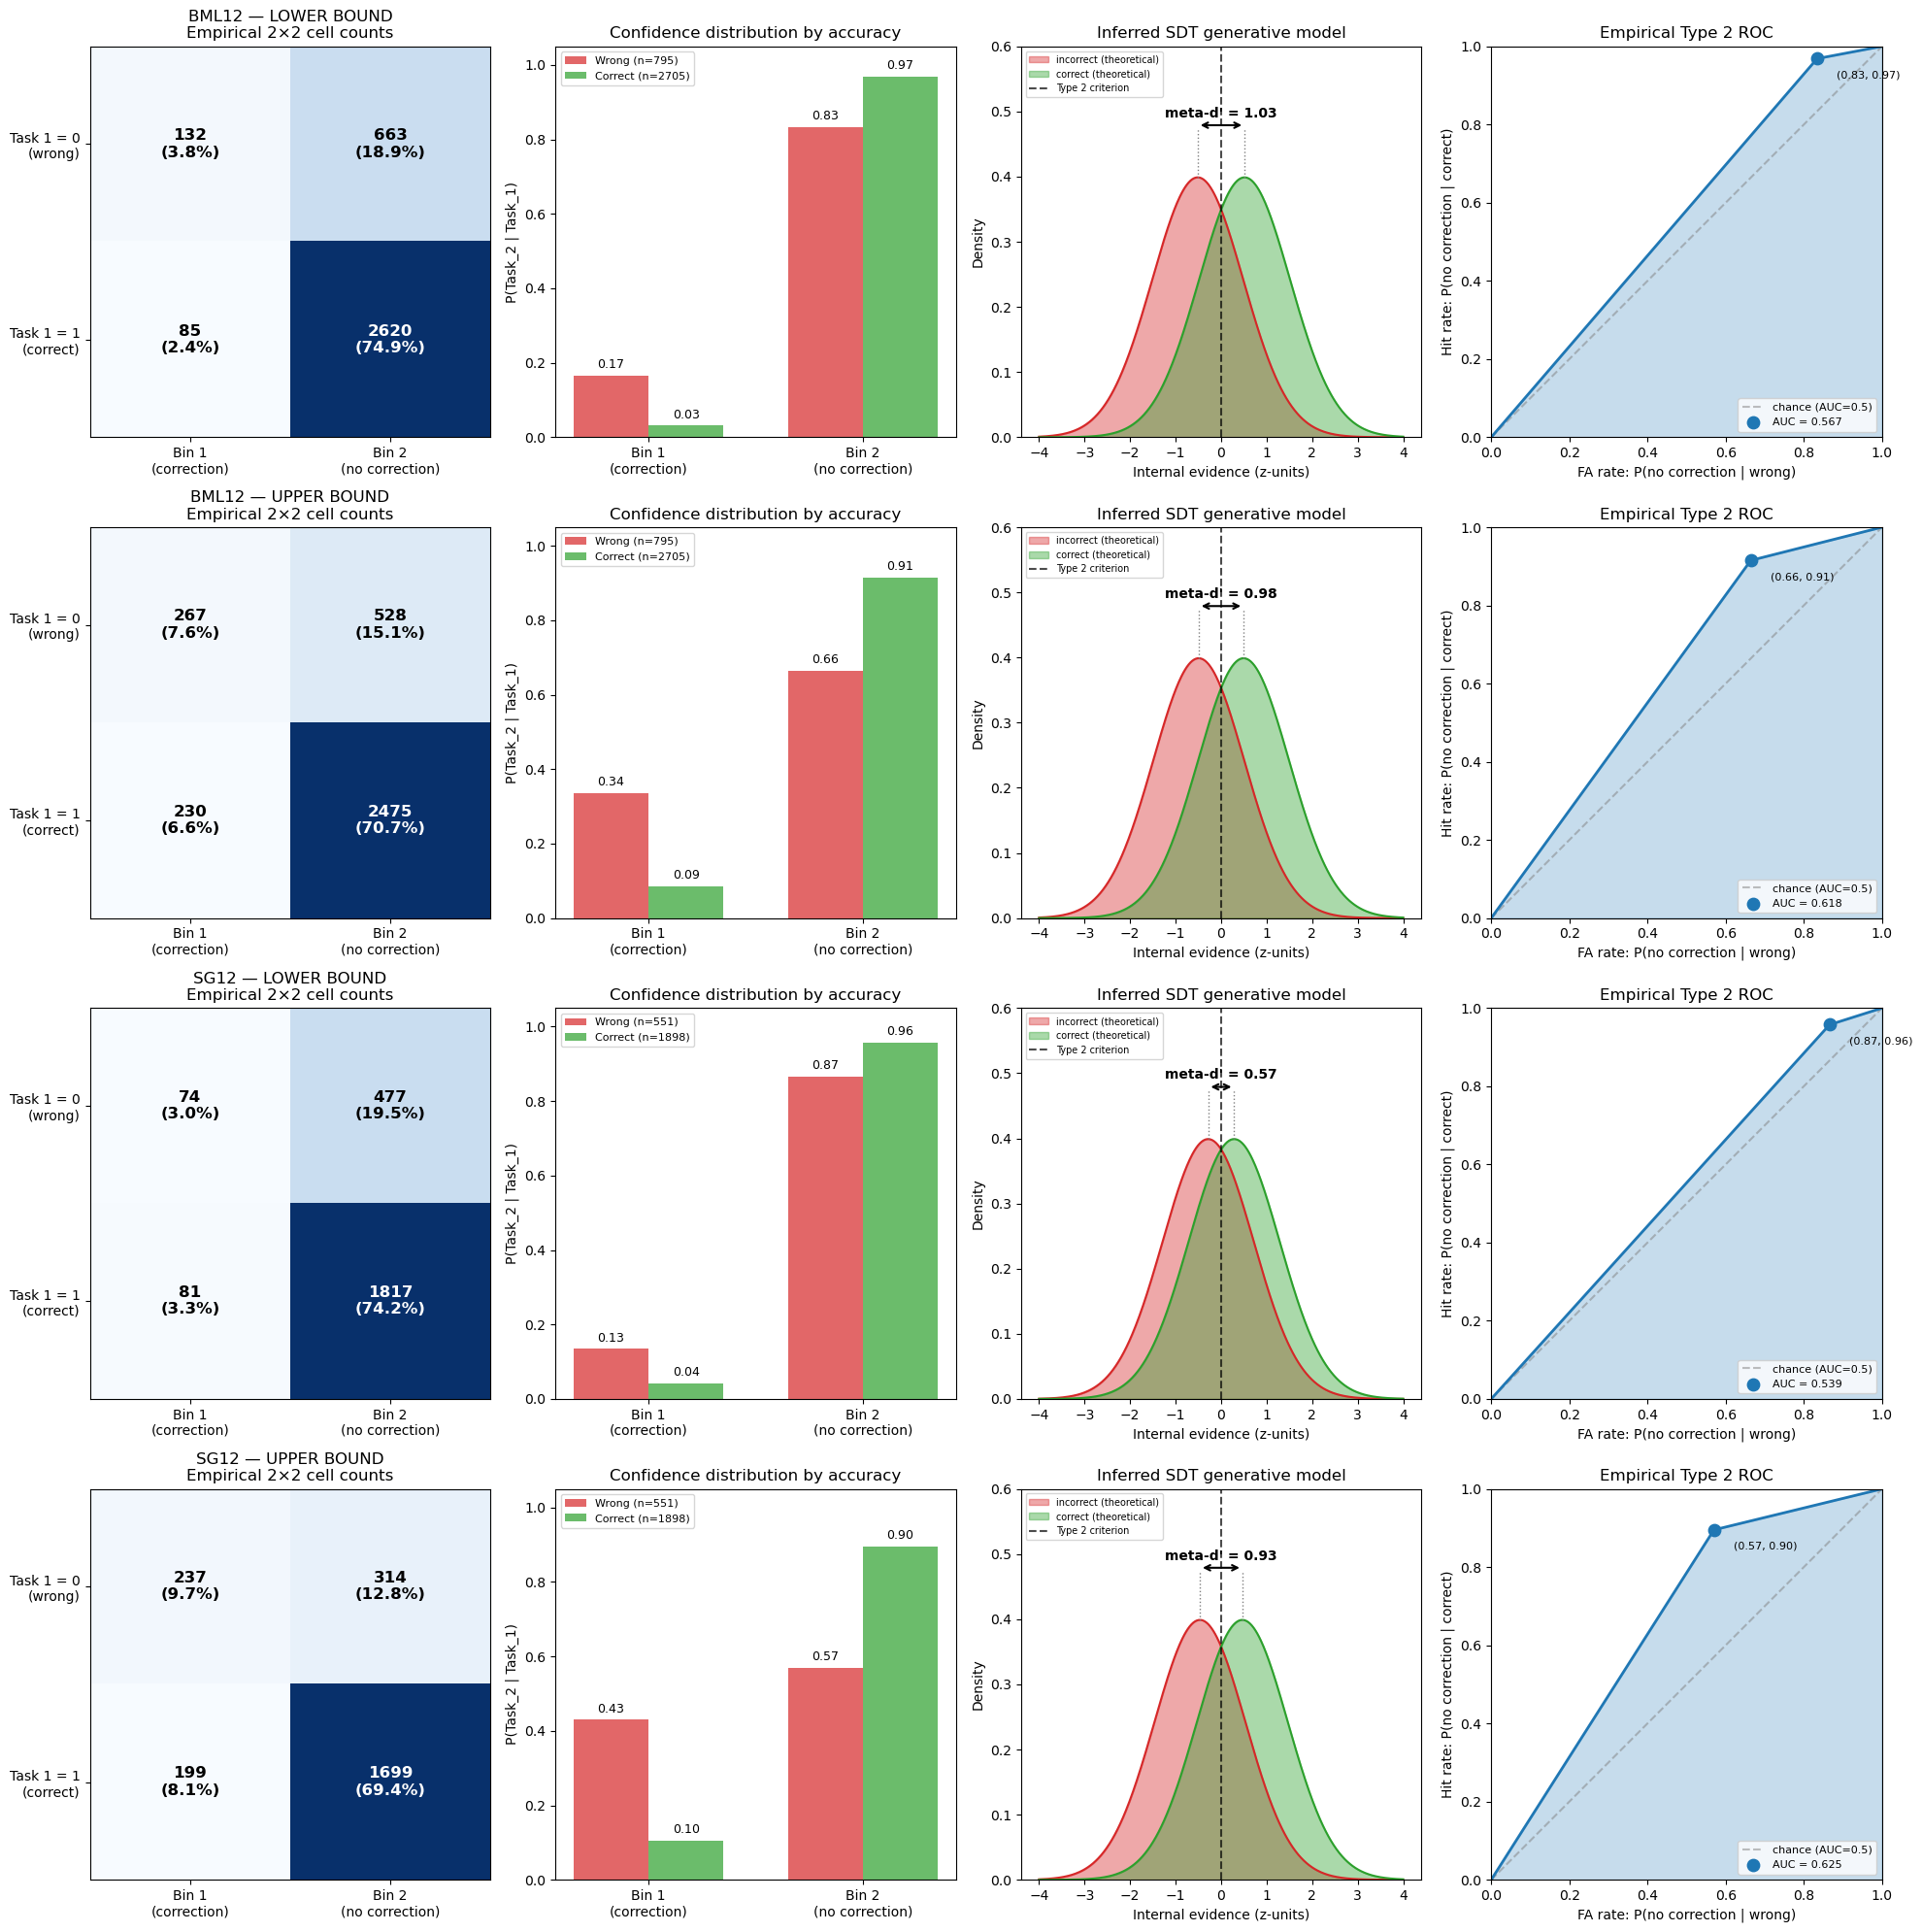

Saved sdt_empirical_and_model_both_bounds.png


In [54]:
# contains superseded exploratory meta-d' analysis

fig, axes = plt.subplots(4, 4, figsize=(20, 20))

# Row 0: BML12 lower bound
plot_study_full(
    bml12_meta_lower['df'],
    bml12_meta_lower['group_metad'],
    bml12_auc_lower['group_auc'],
    'BML12 — LOWER BOUND',
    axes[0],
)

# Row 1: BML12 upper bound
bml12_upper_df = bml12_meta_upper['df'].copy()
bml12_upper_df['Task_2'] = bml12_upper_df['Task_2_Upper']
plot_study_full(
    bml12_upper_df,
    bml12_meta_upper['group_metad'],
    bml12_auc_upper['group_auc'],
    'BML12 — UPPER BOUND',
    axes[1],
)

# Row 2: SG12 lower bound
plot_study_full(
    sg12_meta_lower['df'],
    sg12_meta_lower['group_metad'],
    sg12_auc_lower['group_auc'],
    'SG12 — LOWER BOUND',
    axes[2],
)

# Row 3: SG12 upper bound
sg12_upper_df = sg12_meta_upper['df'].copy()
sg12_upper_df['Task_2'] = sg12_upper_df['Task_2_Upper']
plot_study_full(
    sg12_upper_df,
    sg12_meta_upper['group_metad'],
    sg12_auc_upper['group_auc'],
    'SG12 — UPPER BOUND',
    axes[3],
)

plt.tight_layout()
plt.savefig('sdt_empirical_and_model_both_bounds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved sdt_empirical_and_model_both_bounds.png")

In [55]:
## contains superseded exploratory meta-d' analysis
# LOWER vs UPPER BOUND comparison (Medium definition)

def medium_row(group_df, col_mean, col_lo, col_hi):
    r = group_df[group_df['definition'] == 'Medium'].iloc[0]
    return f"{r[col_mean]:.3f} [{r[col_lo]:.2f}, {r[col_hi]:.2f}]"

print("=" * 144)
print("LOWER vs UPPER BOUND COMPARISON (Medium definition)")
print("=" * 144)

print(f"\n{'Measure':<28}"
      f"{'BML12 lower':<22}{'BML12 upper':<22}"
      f"{'SG12 lower':<22}{'SG12 upper':<22}")
print('-' * 116)

# Meta-d'
bl = medium_row(bml12_meta_lower['group_metad'], 'group_metad_mean', 'group_metad_lo95', 'group_metad_hi95')
bu = medium_row(bml12_meta_upper['group_metad'], 'group_metad_mean', 'group_metad_lo95', 'group_metad_hi95')
sl = medium_row(sg12_meta_lower['group_metad'],  'group_metad_mean', 'group_metad_lo95', 'group_metad_hi95')
su = medium_row(sg12_meta_upper['group_metad'],  'group_metad_mean', 'group_metad_lo95', 'group_metad_hi95')
label = "Group meta-d' [95% CI]"
print(f"{label:<28}{bl:<22}{bu:<22}{sl:<22}{su:<22}")

# AUC
bl = medium_row(bml12_auc_lower['group_auc'], 'group_AUC_mean', 'group_AUC_lo95', 'group_AUC_hi95')
bu = medium_row(bml12_auc_upper['group_auc'], 'group_AUC_mean', 'group_AUC_lo95', 'group_AUC_hi95')
sl = medium_row(sg12_auc_lower['group_auc'],  'group_AUC_mean', 'group_AUC_lo95', 'group_AUC_hi95')
su = medium_row(sg12_auc_upper['group_auc'],  'group_AUC_mean', 'group_AUC_lo95', 'group_AUC_hi95')
print(f"{'Group AUC [95% CI]':<28}{bl:<22}{bu:<22}{sl:<22}{su:<22}")

# Pooled both bounds
def build_pooled(meta_b, meta_s, auc_b, auc_s, bound):
    b_summary = meta_b['ind_medium'][['Part', 'accuracy', 'metad']].merge(
        auc_b['auc_df'][auc_b['auc_df']['definition'] == 'Medium'][['Part', 'AUC']], on='Part'
    )
    s_summary = meta_s['ind_medium'][['Part', 'accuracy', 'metad']].merge(
        auc_s['auc_df'][auc_s['auc_df']['definition'] == 'Medium'][['Part', 'AUC']], on='Part'
    )
    b_summary['Unique_Part'] = 'BML12_' + b_summary['Part'].astype(str)
    s_summary['Unique_Part'] = 'SG12_'  + s_summary['Part'].astype(str)
    b_summary['Study'] = 'BML12'; s_summary['Study'] = 'SG12'
    pooled = pd.concat([b_summary, s_summary], ignore_index=True)
    pooled['Bound'] = bound
    return pooled

pooled_lower = build_pooled(bml12_meta_lower, sg12_meta_lower, bml12_auc_lower, sg12_auc_lower, 'lower')
pooled_upper = build_pooled(bml12_meta_upper, sg12_meta_upper, bml12_auc_upper, sg12_auc_upper, 'upper')

def boot_mean(vals, null_val, n_boot=10000, seed=0):
    vals = np.asarray(vals)
    rng = np.random.default_rng(seed)
    b = np.array([vals[rng.integers(0, len(vals), len(vals))].mean() for _ in range(n_boot)])
    return vals.mean(), np.percentile(b, 2.5), np.percentile(b, 97.5), (b > null_val).mean()

print("\n" + "=" * 100)
print(f"POOLED ESTIMATES (N = {len(pooled_lower)})")
print("=" * 100)
for bound_name, pooled in [('LOWER', pooled_lower), ('UPPER', pooled_upper)]:
    m, lo, hi, p = boot_mean(pooled['metad'].dropna(), 0.0)
    print(f"\n  {bound_name} bound:")
    print(f"    Group meta-d': {m:.3f} [{lo:.3f}, {hi:.3f}]   P(>0) = {p:.3f}")
    m, lo, hi, p = boot_mean(pooled['AUC'].dropna(), 0.5)
    print(f"    Group AUC:     {m:.3f} [{lo:.3f}, {hi:.3f}]   P(>0.5) = {p:.3f}")

# Pooled dissociation under both bounds
print("\n" + "=" * 100)
print("POOLED DISSOCIATION (Spearman, both bounds)")
print("=" * 100)
for bound_name, pooled in [('LOWER', pooled_lower), ('UPPER', pooled_upper)]:
    print(f"\n  {bound_name} bound:")
    for x, y, label in [
        ('accuracy', 'metad', 'Accuracy <-> meta-d'),
        ('accuracy', 'AUC',   'Accuracy <-> Type 2 AUC'),
        ('metad',    'AUC',   'Convergent (metad <-> AUC)'),
    ]:
        rho, p, lo, hi = corr_with_ci(pooled[x], pooled[y])
        print(f"    {label:<32}  rho = {rho:+.3f}, p = {p:.4f}, 95% CI = [{lo:+.3f}, {hi:+.3f}]")

LOWER vs UPPER BOUND COMPARISON (Medium definition)

Measure                     BML12 lower           BML12 upper           SG12 lower            SG12 upper            
--------------------------------------------------------------------------------------------------------------------
Group meta-d' [95% CI]      1.029 [0.86, 1.22]    0.985 [0.85, 1.13]    0.571 [0.42, 0.72]    0.932 [0.76, 1.11]    
Group AUC [95% CI]          0.567 [0.55, 0.58]    0.618 [0.59, 0.64]    0.539 [0.53, 0.55]    0.625 [0.59, 0.66]    

POOLED ESTIMATES (N = 56)

  LOWER bound:
    Group meta-d': 0.832 [0.701, 0.973]   P(>0) = 1.000
    Group AUC:     0.555 [0.545, 0.566]   P(>0.5) = 1.000

  UPPER bound:
    Group meta-d': 0.962 [0.855, 1.071]   P(>0) = 1.000
    Group AUC:     0.621 [0.602, 0.640]   P(>0.5) = 1.000

POOLED DISSOCIATION (Spearman, both bounds)

  LOWER bound:
    Accuracy <-> meta-d               rho = +0.012, p = 0.9295, 95% CI = [-0.281, +0.303]
    Accuracy <-> Type 2 AUC           rho

Pooled sample: 56 translators
  BML12: 32 translators
  SG12:  24 translators
  All Unique_Part values are distinct.

SIDE-BY-SIDE COMPARISON (Medium definition)

Measure                         BML12 (Spanish)           SG12 (German)             
------------------------------------------------------------------------------------
N translators                   32                        24                        
Mean accuracy                   0.778                     0.781                     
Group meta-d' [95% CI]          1.029 [0.86, 1.22]        0.571 [0.42, 0.72]        
P(meta-d' > 0)                  1.000                     1.000                     
Group AUC [95% CI]              0.567 [0.55, 0.58]        0.539 [0.53, 0.55]        
P(AUC > 0.5)                    1.000                     1.000                     

POOLED GROUP-LEVEL ESTIMATES (Medium, N = 56)

Group meta-d':  0.832 [0.701, 0.973]   P(>0) = 1.000
Group AUC:      0.555 [0.545, 0.566]   P(>0.5) = 1.000



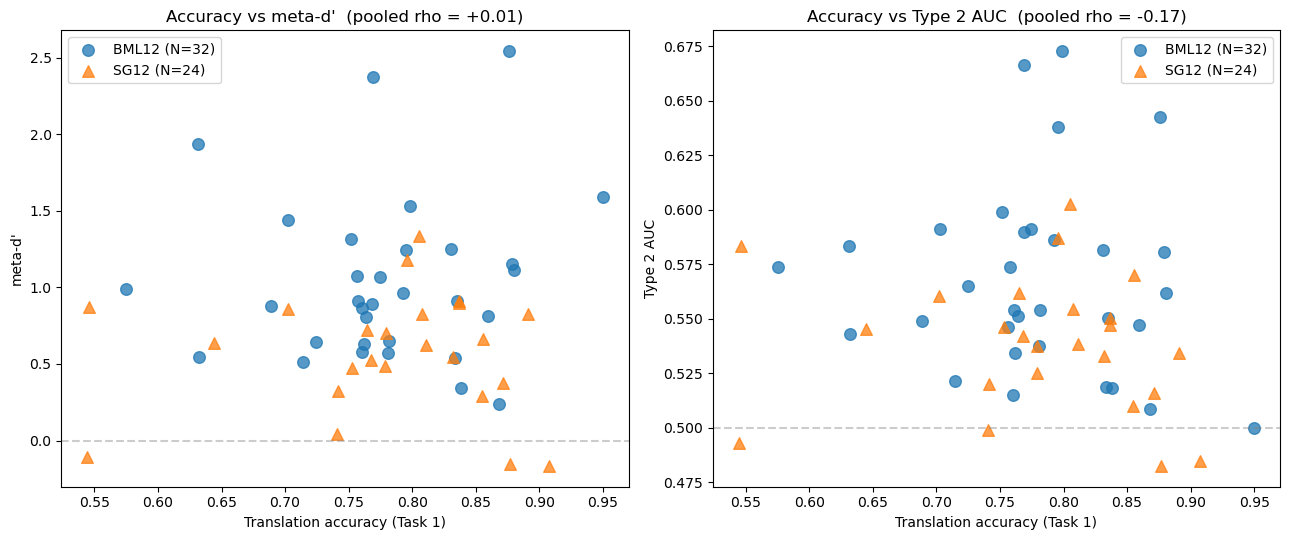


Saved pooled_per_translator_summary.csv and pooled_dissociation_correlations.csv


In [56]:
from scipy.stats import spearmanr

# contains superseded exploratory meta-d' analysis
# pooled summary 
def stamp_study(df, study_name):
    df = df.copy()
    df['Study'] = study_name
    df['Unique_Part'] = study_name + '_' + df['Part'].astype(str)
    return df

bml12_summary = stamp_study(bml12_dissoc['ind_summary'], 'BML12')
sg12_summary  = stamp_study(sg12_dissoc['ind_summary'],  'SG12')
pooled = pd.concat([bml12_summary, sg12_summary], ignore_index=True)

print(f"Pooled sample: {len(pooled)} translators")
print(f"  BML12: {(pooled['Study']=='BML12').sum()} translators")
print(f"  SG12:  {(pooled['Study']=='SG12').sum()} translators")
# no duplicate Unique_Part
assert pooled['Unique_Part'].is_unique, "Duplicate Unique_Part — study labelling failed"
print("  All Unique_Part values are distinct.")


# Side-by-side group-level table (Medium definition)
def medium_row(group_df, col_mean, col_lo, col_hi, col_p):
    r = group_df[group_df['definition'] == 'Medium'].iloc[0]
    return (f"{r[col_mean]:.3f} [{r[col_lo]:.2f}, {r[col_hi]:.2f}]", r[col_p])

bml12_metad_str, bml12_p_metad = medium_row(bml12['group_metad'],
    'group_metad_mean', 'group_metad_lo95', 'group_metad_hi95', 'P_metad_gt_0')
sg12_metad_str,  sg12_p_metad  = medium_row(sg12['group_metad'],
    'group_metad_mean', 'group_metad_lo95', 'group_metad_hi95', 'P_metad_gt_0')
bml12_auc_str, bml12_p_auc = medium_row(bml12_auc['group_auc'],
    'group_AUC_mean', 'group_AUC_lo95', 'group_AUC_hi95', 'P_AUC_gt_0.5')
sg12_auc_str,  sg12_p_auc  = medium_row(sg12_auc['group_auc'],
    'group_AUC_mean', 'group_AUC_lo95', 'group_AUC_hi95', 'P_AUC_gt_0.5')

print("\n" + "=" * 80)
print("SIDE-BY-SIDE COMPARISON (Medium definition)")
print("=" * 80)
print(f"\n{'Measure':<32}{'BML12 (Spanish)':<26}{'SG12 (German)':<26}")
print('-' * 84)
print(f"{'N translators':<32}{len(bml12_summary):<26}{len(sg12_summary):<26}")
print(f"{'Mean accuracy':<32}"
      f"{bml12_summary['accuracy'].mean():<26.3f}"
      f"{sg12_summary['accuracy'].mean():<26.3f}")
lbl_metad_ci = "Group meta-d' [95% CI]"
lbl_metad_p  = "P(meta-d' > 0)"
print(f"{lbl_metad_ci:<32}{bml12_metad_str:<26}{sg12_metad_str:<26}")
print(f"{lbl_metad_p:<32}{bml12_p_metad:<26.3f}{sg12_p_metad:<26.3f}")
print(f"{'Group AUC [95% CI]':<32}{bml12_auc_str:<26}{sg12_auc_str:<26}")
print(f"{'P(AUC > 0.5)':<32}{bml12_p_auc:<26.3f}{sg12_p_auc:<26.3f}")

# Pooled group-level estimates
def boot_mean_ci(vals, n_boot=10000, null_val=0.0, seed=0):
    vals = np.asarray(vals)
    rng = np.random.default_rng(seed)
    boots = np.array([
        vals[rng.integers(0, len(vals), len(vals))].mean()
        for _ in range(n_boot)
    ])
    return vals.mean(), np.percentile(boots, 2.5), np.percentile(boots, 97.5), (boots > null_val).mean()

print("\n" + "=" * 80)
print(f"POOLED GROUP-LEVEL ESTIMATES (Medium, N = {len(pooled)})")
print("=" * 80)
m, lo, hi, p_gt = boot_mean_ci(pooled['metad'].dropna(), null_val=0.0)
print(f"\nGroup meta-d':  {m:.3f} [{lo:.3f}, {hi:.3f}]   P(>0) = {p_gt:.3f}")
m, lo, hi, p_gt = boot_mean_ci(pooled['AUC'].dropna(), null_val=0.5)
print(f"Group AUC:      {m:.3f} [{lo:.3f}, {hi:.3f}]   P(>0.5) = {p_gt:.3f}")


# Pooled dissociation
print("\n" + "=" * 80)
print(f"POOLED DISSOCIATION (Spearman, N = {len(pooled)})")
print("=" * 80)
pooled_corrs = []
for x, y, label in [
    ('accuracy', 'metad', 'Accuracy <-> meta-d'),
    ('accuracy', 'AUC',   'Accuracy <-> Type 2 AUC'),
    ('metad',    'AUC',   'Convergent (metad <-> AUC)'),
]:
    rho, p, lo, hi = corr_with_ci(pooled[x], pooled[y])
    print(f"  {label:<32}  rho = {rho:+.3f}, p = {p:.4f}, 95% CI = [{lo:+.3f}, {hi:+.3f}]")
    pooled_corrs.append({
        'comparison': label, 'rho': rho, 'p_value': p,
        'rho_lo95': lo, 'rho_hi95': hi,
    })

# Combined scatter with study-differentiated markers
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax_idx, (x_col, y_col, ylab, null_y) in enumerate([
    ('accuracy', 'metad', "meta-d'",    0),
    ('accuracy', 'AUC',   'Type 2 AUC', 0.5),
]):
    ax = axes[ax_idx]
    for study_name, color, marker in [('BML12', 'C0', 'o'), ('SG12', 'C1', '^')]:
        sub = pooled[pooled['Study'] == study_name]
        ax.scatter(sub[x_col], sub[y_col], s=70, alpha=0.75,
                   color=color, marker=marker, label=f'{study_name} (N={len(sub)})')
    ax.axhline(null_y, color='gray', ls='--', alpha=0.4)
    ax.set_xlabel('Translation accuracy (Task 1)')
    ax.set_ylabel(ylab)
    rho, _ = spearmanr(pooled[x_col], pooled[y_col])
    ax.set_title(f'Accuracy vs {ylab}  (pooled rho = {rho:+.2f})')
    ax.legend()

plt.tight_layout()
plt.savefig('dissociation_pooled.png', dpi=150, bbox_inches='tight')
plt.show()

# Save
pooled.to_csv('pooled_per_translator_summary.csv', index=False)
pd.DataFrame(pooled_corrs).to_csv('pooled_dissociation_correlations.csv', index=False)
print("\nSaved pooled_per_translator_summary.csv and pooled_dissociation_correlations.csv")

In [57]:
print(f"BML12 raw: {bml12_summary['accuracy'].mean():.6f}")
print(f"SG12 raw:  {sg12_summary['accuracy'].mean():.6f}")

BML12 raw: 0.777920
SG12 raw:  0.781009


In [58]:
# metacognitive monitoring examples

def find_metacognition_examples(trials_csv, ind_summary, study_label,
                                 top_n_translators=3, examples_per_translator=1):
    """
    Pull trials where a high-AUC translator caught and fixed their own error.

    trials_csv:    path to the per-study 2-bin trial CSV
    ind_summary:   per-translator summary (Part, accuracy, metad, AUC)
    """
    
    def recover_next_pu_text(next_edit):
        """Apply CRITT bracket-stripping to the Next_PU_Edit to recover net text."""
        if not isinstance(next_edit, str):
            return ""
        out = []
        i = 0
        while i < len(next_edit):
            ch = next_edit[i]
            if ch == '[':
                j = next_edit.find(']', i + 1)
                if j == -1:
                    out.append(next_edit[i:])
                    break
                deletion = next_edit[i+1:j]
                for _ in range(len(deletion)):
                    if out:
                        out.pop()
                i = j + 1
            else:
                out.append(ch)
                i += 1
        return ''.join(out)

    df = pd.read_csv(trials_csv)
    df = df.dropna(subset=['Task_1']).copy()
    df['Task_1'] = df['Task_1'].astype(int)
    df['Task_2'] = df['Task_2'].astype(int)

    # Identify top-AUC translators (with at least 80 trials, to filter out small-N outliers whose AUC may be unreliable)
    eligible = ind_summary[
        ind_summary['Part'].isin(df['Part'].value_counts()[lambda s: s >= 80].index)
    ].copy()
    top_translators = (eligible
                       .sort_values('AUC', ascending=False)
                       .head(top_n_translators))

    print(f"\n{'=' * 70}")
    print(f"  {study_label} — top {top_n_translators} translators by AUC")
    print('=' * 70)
    print(top_translators[['Part', 'accuracy', 'metad', 'AUC']]
          .round(3).to_string(index=False))

    # For each top translator, find their caught-and-fixed trials
    all_examples = []
    for _, row in top_translators.iterrows():
        part = row['Part']
        their_trials = df[df['Part'] == part]
        caught_and_fixed = their_trials[
            (their_trials['Task_1'] == 0) &
            (their_trials['Task_2'] == 1)
        ].copy()

        print(f"\n{'-' * 70}")
        print(f"  {part}  (AUC = {row['AUC']:.3f}, "
              f"meta-d' = {row['metad']:.2f}, "
              f"accuracy = {row['accuracy']:.2f})")
        print(f"  Total trials: {len(their_trials)}  |  "
              f"caught-and-fixed: {len(caught_and_fixed)}  "
              f"({len(caught_and_fixed)/len(their_trials):.1%})")
        print('-' * 70)

        if len(caught_and_fixed) == 0:
            print("  (no caught-and-fixed trials)")
            continue

        caught_and_fixed['edit_len'] = caught_and_fixed['Prev_PU_Edit'].astype(str).str.len()
        examples = caught_and_fixed.nlargest(examples_per_translator, 'edit_len')

            
        for i, (_, ex) in enumerate(examples.iterrows(), 1):
            corrected = recover_next_pu_text(ex['Next_PU_Edit'])
            print(f"\n  Example {i}  (session {ex['Session']}, trial {ex['Trial_Number']})")
            print(f"    Just-typed (Prev_PU_Edit):      {ex['Prev_PU_Edit']!r}")
            print(f"    Replaced with (Next_PU net):    {corrected!r}")
            print(f"    Fuzzy match score:              {ex['Task_1_Score']:.0f}/100")
            print(f"    Pause duration:                 {ex['Pause']:.0f} ms")
            print(f"    Total fixations in pause:       {ex['Num_Fixations']:.0f}")
            print(f"    Relevant fixations:             {ex['Relevant_Fixations']:.0f}  "
                  f"(on just-typed PU's target tokens)")
            print(f"    Next PU (raw edit):             {ex['Next_PU_Edit']!r}")

        examples['Study'] = study_label
        examples['Part_AUC'] = row['AUC']
        all_examples.append(examples)

    if all_examples:
        return pd.concat(all_examples, ignore_index=True)
    return pd.DataFrame()


# ------------------------------------------------------------------
# Run 
bml12_examples = find_metacognition_examples(
    'BML12_2bin_trials.csv',
    bml12_dissoc['ind_summary'],
    'BML12 (Spanish)',
    top_n_translators=3,
    examples_per_translator=1,
)

sg12_examples = find_metacognition_examples(
    'SG12_2bin_trials.csv',
    sg12_dissoc['ind_summary'],
    'SG12 (German)',
    top_n_translators=3,
    examples_per_translator=1,
)

# Save
combined = pd.concat([bml12_examples, sg12_examples], ignore_index=True)
combined.to_csv('metacognition_examples.csv', index=False)
print(f"\nSaved {len(combined)} examples to metacognition_examples.csv")


  BML12 (Spanish) — top 3 translators by AUC
Part  accuracy  metad   AUC
 P04     0.798  1.530 0.673
 P30     0.876  2.543 0.643
 P31     0.752  1.318 0.599

----------------------------------------------------------------------
  P04  (AUC = 0.673, meta-d' = 1.53, accuracy = 0.80)
  Total trials: 129  |  caught-and-fixed: 10  (7.8%)
----------------------------------------------------------------------

  Example 1  (session P04_T2, trial 147)
    Just-typed (Prev_PU_Edit):      'reciban_salario'
    Replaced with (Next_PU net):    'perciban_salarios_por_de'
    Fuzzy match score:              38/100
    Pause duration:                 1281 ms
    Total fixations in pause:       5
    Relevant fixations:             4  (on just-typed PU's target tokens)
    Next PU (raw edit):             '[ciban_salarioer]perciban_salarios_por_de'

----------------------------------------------------------------------
  P30  (AUC = 0.643, meta-d' = 2.54, accuracy = 0.88)
  Total trials: 113  |  caug

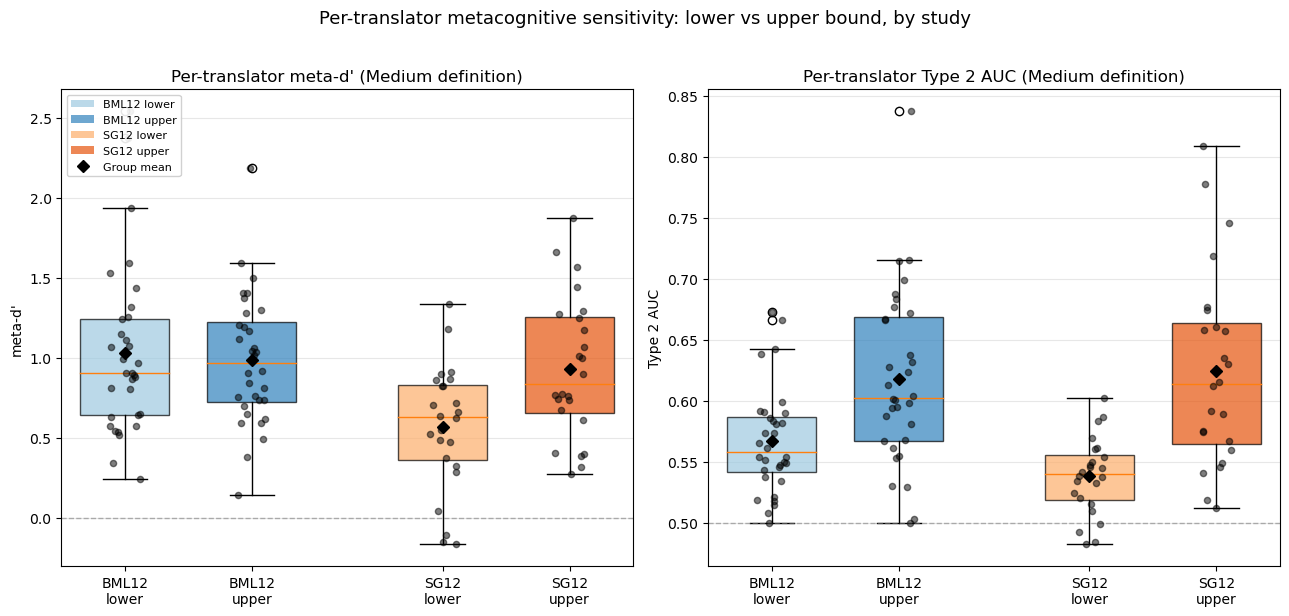

Saved per_translator_boxplot.png


In [59]:
# Contains superseded exploratory analysis on meta-d'


# Plot 1: Per-translator meta-d' and AUC, by study and bound
# Combine all four per-translator summary dataframes into long format.

def make_summary(meta_result, auc_result, study, bound):
    """Build a per-translator summary frame with Study/Bound labels."""
    df = meta_result['ind_medium'][['Part', 'accuracy', 'metad']].merge(
        auc_result['auc_df'][auc_result['auc_df']['definition'] == 'Medium'][['Part', 'AUC']],
        on='Part',
    )
    df['Study'] = study
    df['Bound'] = bound
    return df

combined = pd.concat([
    make_summary(bml12_meta_lower, bml12_auc_lower, 'BML12', 'lower'),
    make_summary(bml12_meta_upper, bml12_auc_upper, 'BML12', 'upper'),
    make_summary(sg12_meta_lower,  sg12_auc_lower,  'SG12',  'lower'),
    make_summary(sg12_meta_upper,  sg12_auc_upper,  'SG12',  'upper'),
], ignore_index=True)

# ------------------------------------------------------------------
# Two-panel figure: meta-d' left, AUC right
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

positions      = [1, 2, 3.5, 4.5]
box_labels     = ['BML12\nlower', 'BML12\nupper', 'SG12\nlower', 'SG12\nupper']
box_colours    = ['#9ecae1', '#3182bd', '#fdae6b', '#e6550d']   # paired light/dark blue, light/dark orange
group_combos   = [('BML12', 'lower'), ('BML12', 'upper'),
                  ('SG12',  'lower'), ('SG12',  'upper')]

metad_data = [combined[(combined['Study'] == s) & (combined['Bound'] == b)]['metad'].values
              for s, b in group_combos]
bp1 = axes[0].boxplot(metad_data, positions=positions, widths=0.7,
                       patch_artist=True, showmeans=True,
                       meanprops={'marker': 'D', 'markerfacecolor': 'black',
                                  'markeredgecolor': 'black', 'markersize': 6})
for patch, c in zip(bp1['boxes'], box_colours):
    patch.set_facecolor(c); patch.set_alpha(0.7)

rng = np.random.default_rng(0)
for pos, dat in zip(positions, metad_data):
    jitter = rng.uniform(-0.12, 0.12, size=len(dat))
    axes[0].scatter(np.full(len(dat), pos) + jitter, dat,
                    s=20, alpha=0.5, color='black', zorder=3)

axes[0].axhline(0, color='gray', ls='--', lw=1, alpha=0.6)
axes[0].set_xticks(positions)
axes[0].set_xticklabels(box_labels)
axes[0].set_ylabel("meta-d'")
axes[0].set_title("Per-translator meta-d' (Medium definition)")
axes[0].grid(axis='y', alpha=0.3)

# AUC
auc_data = [combined[(combined['Study'] == s) & (combined['Bound'] == b)]['AUC'].values
            for s, b in group_combos]
bp2 = axes[1].boxplot(auc_data, positions=positions, widths=0.7,
                      patch_artist=True, showmeans=True,
                      meanprops={'marker': 'D', 'markerfacecolor': 'black',
                                 'markeredgecolor': 'black', 'markersize': 6})
for patch, c in zip(bp2['boxes'], box_colours):
    patch.set_facecolor(c); patch.set_alpha(0.7)

for pos, dat in zip(positions, auc_data):
    jitter = rng.uniform(-0.12, 0.12, size=len(dat))
    axes[1].scatter(np.full(len(dat), pos) + jitter, dat,
                    s=20, alpha=0.5, color='black', zorder=3)

axes[1].axhline(0.5, color='gray', ls='--', lw=1, alpha=0.6)
axes[1].set_xticks(positions)
axes[1].set_xticklabels(box_labels)
axes[1].set_ylabel('Type 2 AUC')
axes[1].set_title('Per-translator Type 2 AUC (Medium definition)')
axes[1].grid(axis='y', alpha=0.3)

# Legend meta-d'
from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor='#9ecae1', alpha=0.7, label='BML12 lower'),
    Patch(facecolor='#3182bd', alpha=0.7, label='BML12 upper'),
    Patch(facecolor='#fdae6b', alpha=0.7, label='SG12 lower'),
    Patch(facecolor='#e6550d', alpha=0.7, label='SG12 upper'),
    plt.Line2D([], [], marker='D', color='black', linestyle='',
               markersize=6, label='Group mean'),
]
axes[0].legend(handles=legend_elems, loc='upper left', fontsize=8, framealpha=0.9)

plt.suptitle('Per-translator metacognitive sensitivity: lower vs upper bound, by study',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('per_translator_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved per_translator_boxplot.png")

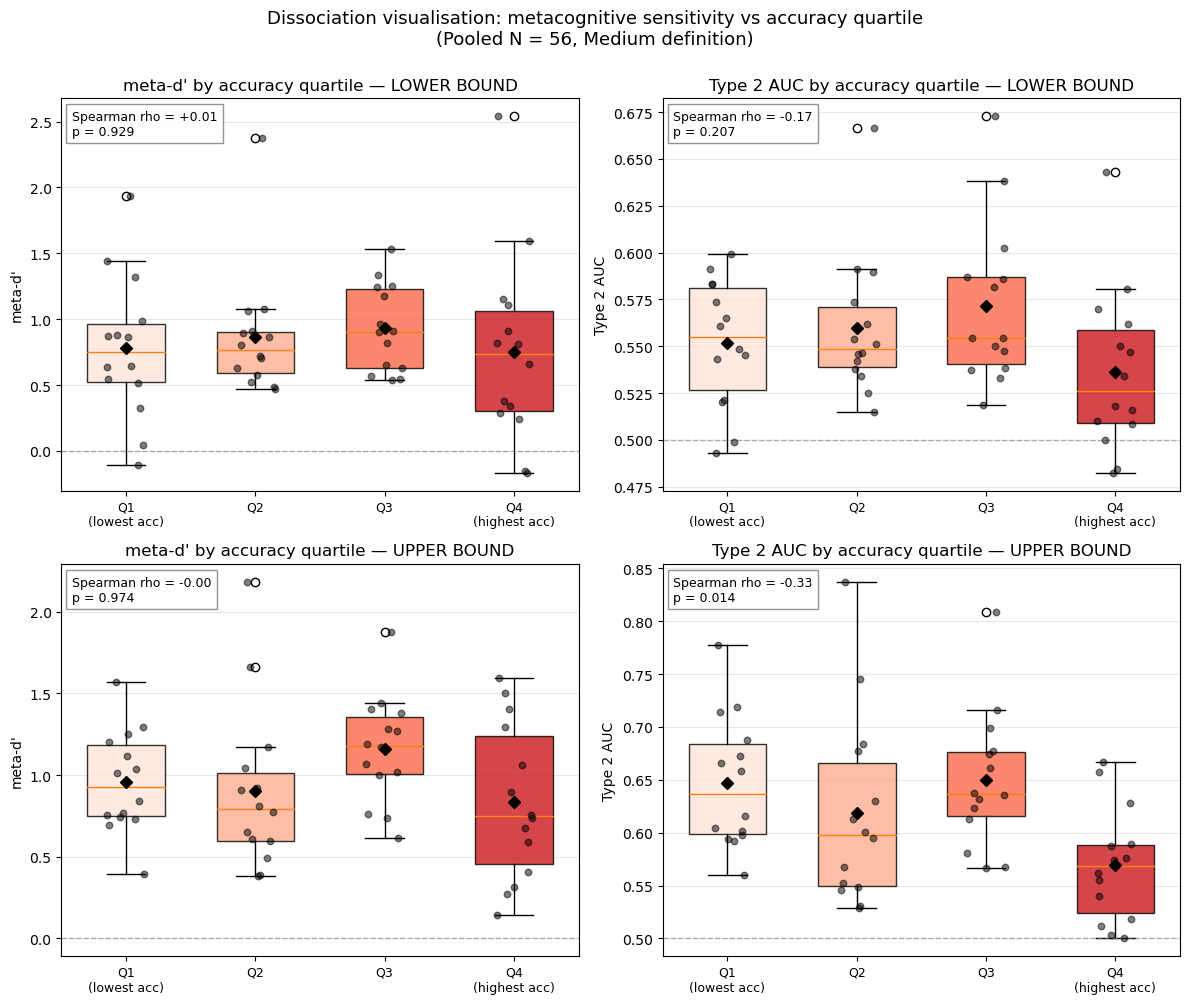

Saved quartile_dissociation.png


In [60]:
# Contains superseded exploratory analysis on meta-d'

# Plots 3 & 4: Metacognitive sensitivity by accuracy quartile
# (under both bounds - upper bound is the more informative one for the

# Build a pooled dataframe with quartile labels for both bounds
def add_quartiles(meta_b_low, meta_s_low, meta_b_up, meta_s_up,
                  auc_b_low, auc_s_low, auc_b_up, auc_s_up):
    """Combine all per-translator estimates into long format with quartile labels."""
    def merge_one(meta, auc, study, bound):
        df = meta['ind_medium'][['Part', 'accuracy', 'metad']].merge(
            auc['auc_df'][auc['auc_df']['definition'] == 'Medium'][['Part', 'AUC']], on='Part'
        )
        df['Study'] = study; df['Bound'] = bound
        return df

    pooled = pd.concat([
        merge_one(meta_b_low, auc_b_low, 'BML12', 'lower'),
        merge_one(meta_b_up,  auc_b_up,  'BML12', 'upper'),
        merge_one(meta_s_low, auc_s_low, 'SG12',  'lower'),
        merge_one(meta_s_up,  auc_s_up,  'SG12',  'upper'),
    ], ignore_index=True)

    # Assign quartiles across pooled sample
    pooled_lower = pooled[pooled['Bound'] == 'lower'].copy()
    pooled_lower['acc_quartile'] = pd.qcut(
        pooled_lower['accuracy'], q=4,
        labels=['Q1\n(lowest acc)', 'Q2', 'Q3', 'Q4\n(highest acc)']
    )

    pooled_upper = pooled[pooled['Bound'] == 'upper'].copy()
    quartile_map = pooled_lower.set_index(['Study', 'Part'])['acc_quartile'].to_dict()
    pooled_upper['acc_quartile'] = pooled_upper.apply(
        lambda r: quartile_map[(r['Study'], r['Part'])], axis=1
    )
    return pd.concat([pooled_lower, pooled_upper], ignore_index=True)


pooled = add_quartiles(
    bml12_meta_lower, sg12_meta_lower, bml12_meta_upper, sg12_meta_upper,
    bml12_auc_lower,  sg12_auc_lower,  bml12_auc_upper,  sg12_auc_upper,
)

# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

quartile_order = ['Q1\n(lowest acc)', 'Q2', 'Q3', 'Q4\n(highest acc)']
quartile_colours = ['#fee5d9', '#fcae91', '#fb6a4a', '#cb181d']   # light to dark red

rng = np.random.default_rng(0)

def plot_panel(ax, bound, measure, null_val, ylabel, title):
    sub = pooled[pooled['Bound'] == bound]
    data_by_q = [sub[sub['acc_quartile'] == q][measure].values for q in quartile_order]

    bp = ax.boxplot(data_by_q, positions=[1, 2, 3, 4], widths=0.6,
                    patch_artist=True, showmeans=True,
                    meanprops={'marker': 'D', 'markerfacecolor': 'black',
                               'markeredgecolor': 'black', 'markersize': 6})
    for patch, c in zip(bp['boxes'], quartile_colours):
        patch.set_facecolor(c); patch.set_alpha(0.8)

    # Overlay individual translators
    for pos, dat in zip([1, 2, 3, 4], data_by_q):
        jitter = rng.uniform(-0.15, 0.15, size=len(dat))
        ax.scatter(np.full(len(dat), pos) + jitter, dat,
                   s=22, alpha=0.5, color='black', zorder=3)

    ax.axhline(null_val, color='gray', ls='--', lw=1, alpha=0.6)
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(quartile_order, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)

    # Spearman correlation across all 56 with the underlying continuous accuracy
    from scipy.stats import spearmanr
    rho, p = spearmanr(sub['accuracy'], sub[measure])
    ax.text(0.02, 0.97,
            f"Spearman rho = {rho:+.2f}\np = {p:.3f}",
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85))

plot_panel(axes[0, 0], 'lower', 'metad', 0.0,
           "meta-d'", "meta-d' by accuracy quartile — LOWER BOUND")
plot_panel(axes[0, 1], 'lower', 'AUC',  0.5,
           "Type 2 AUC", "Type 2 AUC by accuracy quartile — LOWER BOUND")
plot_panel(axes[1, 0], 'upper', 'metad', 0.0,
           "meta-d'", "meta-d' by accuracy quartile — UPPER BOUND")
plot_panel(axes[1, 1], 'upper', 'AUC',  0.5,
           "Type 2 AUC", "Type 2 AUC by accuracy quartile — UPPER BOUND")

plt.suptitle('Dissociation visualisation: metacognitive sensitivity vs accuracy quartile\n'
             '(Pooled N = 56, Medium definition)', fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('quartile_dissociation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved quartile_dissociation.png")

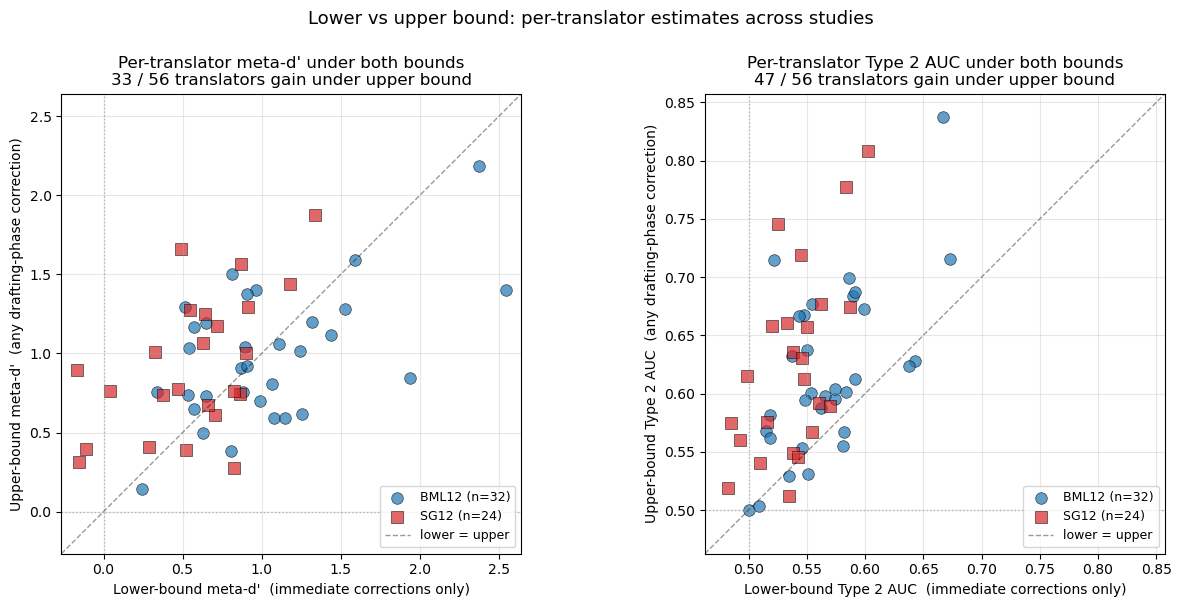

Saved per_translator_scatter.png


In [61]:
# Contains superseded exploratory analysis on meta-d'

# Per-translator scatter: lower-bound vs upper-bound estimates
# Combine the per-translator estimates into a single frame
def assemble(meta_low, meta_up, auc_low, auc_up, study):
    """Build a per-translator frame with both bounds, both measures."""
    low_metad = meta_low['ind_medium'][['Part', 'metad']].rename(columns={'metad': 'metad_lower'})
    up_metad  = meta_up['ind_medium'][['Part', 'metad']].rename(columns={'metad': 'metad_upper'})
    low_auc   = auc_low['auc_df'][auc_low['auc_df']['definition'] == 'Medium'][
                    ['Part', 'AUC']].rename(columns={'AUC': 'AUC_lower'})
    up_auc    = auc_up['auc_df'][auc_up['auc_df']['definition'] == 'Medium'][
                    ['Part', 'AUC']].rename(columns={'AUC': 'AUC_upper'})
    df = low_metad.merge(up_metad, on='Part').merge(low_auc, on='Part').merge(up_auc, on='Part')
    df['Study'] = study
    return df

scatter_df = pd.concat([
    assemble(bml12_meta_lower, bml12_meta_upper, bml12_auc_lower, bml12_auc_upper, 'BML12'),
    assemble(sg12_meta_lower,  sg12_meta_upper,  sg12_auc_lower,  sg12_auc_upper,  'SG12'),
], ignore_index=True)

N_total = len(scatter_df)   # total translators across all studies

# ------------------------------------------------------------------
# Figure - Left = meta-d', right = AUC.
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
study_colours = {'BML12': '#1f77b4', 'SG12': '#d62728'}
study_markers = {'BML12': 'o', 'SG12': 's'}

# Panel 1: meta-d'
ax = axes[0]
for study, sub in scatter_df.groupby('Study'):
    ax.scatter(sub['metad_lower'], sub['metad_upper'],
               s=70, alpha=0.7, color=study_colours[study],
               marker=study_markers[study], edgecolor='black', linewidth=0.5,
               label=f"{study} (n={len(sub)})")

metad_min = min(scatter_df['metad_lower'].min(), scatter_df['metad_upper'].min()) - 0.1
metad_max = max(scatter_df['metad_lower'].max(), scatter_df['metad_upper'].max()) + 0.1
ax.plot([metad_min, metad_max], [metad_min, metad_max],
        'k--', alpha=0.4, lw=1, label='lower = upper')
ax.axhline(0, color='gray', ls=':', lw=1, alpha=0.5)
ax.axvline(0, color='gray', ls=':', lw=1, alpha=0.5)

above_metad = (scatter_df['metad_upper'] > scatter_df['metad_lower']).sum()
ax.set_xlabel("Lower-bound meta-d'  (immediate corrections only)")
ax.set_ylabel("Upper-bound meta-d'  (any drafting-phase correction)")
ax.set_title(f"Per-translator meta-d' under both bounds\n"
             f"{above_metad} / {N_total} translators gain under upper bound")
ax.set_xlim(metad_min, metad_max)
ax.set_ylim(metad_min, metad_max)
ax.set_aspect('equal')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

#Panel 2: AUC
ax = axes[1]
for study, sub in scatter_df.groupby('Study'):
    ax.scatter(sub['AUC_lower'], sub['AUC_upper'],
               s=70, alpha=0.7, color=study_colours[study],
               marker=study_markers[study], edgecolor='black', linewidth=0.5,
               label=f"{study} (n={len(sub)})")

auc_min = min(scatter_df['AUC_lower'].min(), scatter_df['AUC_upper'].min()) - 0.02
auc_max = max(scatter_df['AUC_lower'].max(), scatter_df['AUC_upper'].max()) + 0.02
ax.plot([auc_min, auc_max], [auc_min, auc_max],
        'k--', alpha=0.4, lw=1, label='lower = upper')
ax.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.5)
ax.axvline(0.5, color='gray', ls=':', lw=1, alpha=0.5)

above_auc = (scatter_df['AUC_upper'] > scatter_df['AUC_lower']).sum()
ax.set_xlabel("Lower-bound Type 2 AUC  (immediate corrections only)")
ax.set_ylabel("Upper-bound Type 2 AUC  (any drafting-phase correction)")
ax.set_title(f"Per-translator Type 2 AUC under both bounds\n"
             f"{above_auc} / {N_total} translators gain under upper bound")
ax.set_xlim(auc_min, auc_max)
ax.set_ylim(auc_min, auc_max)
ax.set_aspect('equal')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('Lower vs upper bound: per-translator estimates across studies',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('per_translator_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved per_translator_scatter.png")

---

## Task 1 threshold sensitivity analysis

The Type 1 outcome is defined by thresholding `Task_1_Score` (the fuzzy match between the
text typed in a production unit and the corresponding span of the final target text) at 75.
Because that value is a free parameter, the full analysis is repeated here at four
alternative thresholds.

`Task_1_Score` is retained in the trial tables, so re-thresholding requires no re-run of the
data pipeline: `Task_1` is simply recomputed as `Task_1_Score >= threshold`.

Reported for each threshold: Task 1 accuracy, group mean AUROC2 under each bound with a
bootstrap 95% CI over participants, and P(AUROC2 > 0.5).


In [62]:
# Threshold sensitivity

from sklearn.metrics import roc_auc_score

THRESHOLDS = [65, 70, 75, 80, 85]   # 75 is the primary analysis
N_BOOT     = 10000
SEED       = 0

sens_frames = {}
for f, lab in [('BML12_2bin_trials.csv', 'BML12'),
               ('SG12_2bin_trials.csv',  'SG12')]:
    d = pd.read_csv(f).dropna(subset=['Task_1_Score']).copy()
    sens_frames[lab] = d
    print(f"{lab}: {len(d)} gradeable trials, {d['Part'].nunique()} participants")

for lab, d in sens_frames.items():
    ok = (d['Task_1'].astype(int) == (d['Task_1_Score'] >= 75).astype(int)).all()
    print(f"{lab}: stored Task_1 == (Task_1_Score >= 75)? {ok}")


BML12: 3500 gradeable trials, 32 participants
SG12: 2449 gradeable trials, 24 participants
BML12: stored Task_1 == (Task_1_Score >= 75)? True
SG12: stored Task_1 == (Task_1_Score >= 75)? True


In [63]:
# Threshold sensitivity
def boot_mean(vals, null_val=0.5, n_boot=N_BOOT, seed=SEED):
    """Bootstrap the mean over participants. Returns (mean, lo95, hi95, P(>null))."""
    vals = np.asarray(vals, dtype=float)
    rng  = np.random.default_rng(seed)
    boots = np.array([vals[rng.integers(0, len(vals), len(vals))].mean()
                      for _ in range(n_boot)])
    return (vals.mean(), np.percentile(boots, 2.5),
            np.percentile(boots, 97.5), (boots > null_val).mean())


def auroc2_at_threshold(df, threshold, task2_col):
    """Per-participant AUROC2 with Task 1 defined by the given fuzzy-score threshold.

    Participants whose Task 1 is constant at this threshold are skipped, since
    AUROC2 is undefined when one outcome class is empty.
    """
    d = df.copy()
    d['T1'] = (d['Task_1_Score'] >= threshold).astype(int)
    vals, skipped = [], []
    for part, g in d.groupby('Part'):
        if g['T1'].nunique() < 2:
            skipped.append(part)
            continue
        vals.append(roc_auc_score(g['T1'], g[task2_col]))
    return np.array(vals), skipped


In [64]:
# Threshold sensitivity: per-corpus results
sens_rows = []

for lab, d in sens_frames.items():
    print()
    print('=' * 84)
    print(f"  {lab} - Task 1 threshold sensitivity")
    print('=' * 84)
    print(f"{'Thr':>4} {'Task1 acc':>11} {'n':>4}   "
          f"{'Lower-bound AUROC2':<32} {'Upper-bound AUROC2':<32}")
    print('-' * 88)

    for thr in THRESHOLDS:
        acc = (d['Task_1_Score'] >= thr).mean()
        lo_vals, lo_skip = auroc2_at_threshold(d, thr, 'Task_2')
        up_vals, up_skip = auroc2_at_threshold(d, thr, 'Task_2_Upper')

        lo = boot_mean(lo_vals)
        up = boot_mean(up_vals)

        marker = ' *' if thr == 75 else '  '
        print(f"{thr:>4}{marker}{acc:>9.3f} {len(lo_vals):>4}   "
              f"{lo[0]:.3f} [{lo[1]:.3f}, {lo[2]:.3f}] P={lo[3]:.3f}   "
              f"{up[0]:.3f} [{up[1]:.3f}, {up[2]:.3f}] P={up[3]:.3f}")

        if lo_skip or up_skip:
            print(f"       (skipped, Task 1 constant: {sorted(set(lo_skip) | set(up_skip))})")

        sens_rows.append({
            'study': lab, 'threshold': thr, 'task1_accuracy': acc,
            'n_participants': len(lo_vals),
            'lower_mean': lo[0], 'lower_lo95': lo[1], 'lower_hi95': lo[2], 'lower_P': lo[3],
            'upper_mean': up[0], 'upper_lo95': up[1], 'upper_hi95': up[2], 'upper_P': up[3],
        })

print()
print("* = primary analysis")



  BML12 - Task 1 threshold sensitivity
 Thr   Task1 acc    n   Lower-bound AUROC2               Upper-bound AUROC2              
----------------------------------------------------------------------------------------
  65      0.798   32   0.563 [0.547, 0.580] P=1.000   0.613 [0.588, 0.641] P=1.000
  70      0.780   32   0.564 [0.550, 0.579] P=1.000   0.615 [0.589, 0.643] P=1.000
  75 *    0.773   32   0.567 [0.553, 0.582] P=1.000   0.618 [0.594, 0.644] P=1.000
  80      0.760   32   0.564 [0.550, 0.578] P=1.000   0.613 [0.590, 0.637] P=1.000
  85      0.733   32   0.559 [0.547, 0.572] P=1.000   0.607 [0.586, 0.631] P=1.000

  SG12 - Task 1 threshold sensitivity
 Thr   Task1 acc    n   Lower-bound AUROC2               Upper-bound AUROC2              
----------------------------------------------------------------------------------------
  65      0.800   24   0.530 [0.515, 0.545] P=1.000   0.613 [0.580, 0.648] P=1.000
  70      0.787   24   0.536 [0.521, 0.550] P=1.000   0.621 [0.58

In [65]:
# pooled across both corpora
print()
print('=' * 84)
print("  POOLED - Task 1 threshold sensitivity")
print('=' * 84)
print(f"{'Thr':>4} {'n':>4}   {'Lower-bound AUROC2':<32} {'Upper-bound AUROC2':<32}")
print('-' * 76)

for thr in THRESHOLDS:
    pooled_lo, pooled_up = [], []
    for lab, d in sens_frames.items():
        lo_vals, _ = auroc2_at_threshold(d, thr, 'Task_2')
        up_vals, _ = auroc2_at_threshold(d, thr, 'Task_2_Upper')
        pooled_lo.extend(lo_vals)
        pooled_up.extend(up_vals)

    lo = boot_mean(pooled_lo)
    up = boot_mean(pooled_up)
    marker = ' *' if thr == 75 else '  '
    print(f"{thr:>4}{marker}{len(pooled_lo):>4}   "
          f"{lo[0]:.3f} [{lo[1]:.3f}, {lo[2]:.3f}] P={lo[3]:.3f}   "
          f"{up[0]:.3f} [{up[1]:.3f}, {up[2]:.3f}] P={up[3]:.3f}")

    sens_rows.append({
        'study': 'Pooled', 'threshold': thr, 'task1_accuracy': np.nan,
        'n_participants': len(pooled_lo),
        'lower_mean': lo[0], 'lower_lo95': lo[1], 'lower_hi95': lo[2], 'lower_P': lo[3],
        'upper_mean': up[0], 'upper_lo95': up[1], 'upper_hi95': up[2], 'upper_P': up[3],
    })

sens_df = pd.DataFrame(sens_rows)
sens_df.to_csv('threshold_sensitivity.csv', index=False)
print()
print("Saved threshold_sensitivity.csv")

p = sens_df[sens_df['study'] == 'Pooled']
print()
print(f"Pooled range across thresholds {THRESHOLDS[0]}-{THRESHOLDS[-1]}:")
print(f"  Lower bound: {p['lower_mean'].min():.3f} to {p['lower_mean'].max():.3f} "
      f"(spread {p['lower_mean'].max() - p['lower_mean'].min():.3f})")
print(f"  Upper bound: {p['upper_mean'].min():.3f} to {p['upper_mean'].max():.3f} "
      f"(spread {p['upper_mean'].max() - p['upper_mean'].min():.3f})")
all_excl = bool((sens_df['lower_lo95'] > 0.5).all() and (sens_df['upper_lo95'] > 0.5).all())
print(f"  All CIs exclude 0.5: {all_excl}")



  POOLED - Task 1 threshold sensitivity
 Thr    n   Lower-bound AUROC2               Upper-bound AUROC2              
----------------------------------------------------------------------------
  65    56   0.549 [0.537, 0.561] P=1.000   0.613 [0.593, 0.634] P=1.000
  70    56   0.552 [0.541, 0.563] P=1.000   0.617 [0.598, 0.639] P=1.000
  75 *  56   0.555 [0.545, 0.566] P=1.000   0.621 [0.602, 0.640] P=1.000
  80    56   0.554 [0.544, 0.564] P=1.000   0.619 [0.601, 0.637] P=1.000
  85    56   0.551 [0.542, 0.560] P=1.000   0.615 [0.597, 0.633] P=1.000

Saved threshold_sensitivity.csv

Pooled range across thresholds 65-85:
  Lower bound: 0.549 to 0.555 (spread 0.006)
  Upper bound: 0.613 to 0.621 (spread 0.008)
  All CIs exclude 0.5: True


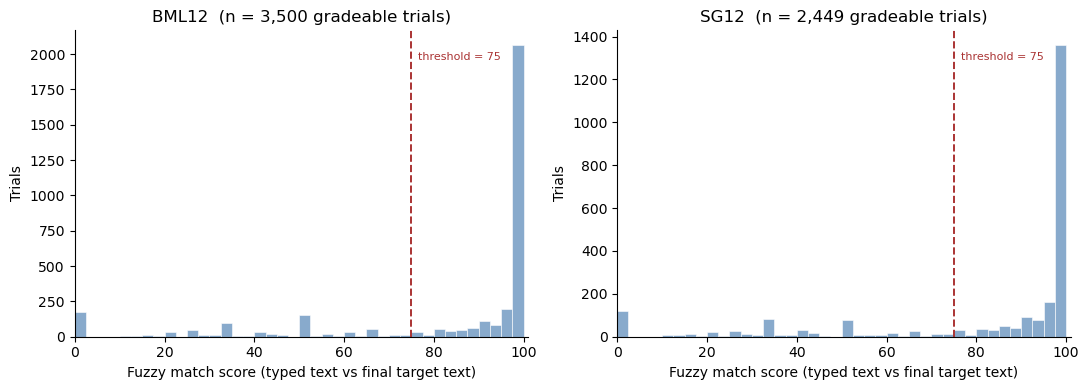


Proportion of gradeable trials in the intervals flanking the threshold:
  BML12: [70,75) = 0.71%   [75,80) = 1.29%   at 100 = 57.3%
  SG12: [70,75) = 1.18%   [75,80) = 1.76%   at 100 = 52.6%


In [66]:
# distribution of Task 1 fuzzy scores with the threshold marked
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (lab, d) in zip(axes, sens_frames.items()):
    s = d['Task_1_Score']
    ax.hist(s, bins=np.arange(0, 102.5, 2.5), color='#88AACC',
            edgecolor='white', linewidth=0.4)
    ax.axvline(75, color='#AA3333', ls='--', lw=1.4)
    ax.text(75, ax.get_ylim()[1] * 0.93, '  threshold = 75',
            color='#AA3333', fontsize=8, va='top')
    ax.set_xlabel('Fuzzy match score (typed text vs final target text)')
    ax.set_ylabel('Trials')
    ax.set_title(f'{lab}  (n = {len(s):,} gradeable trials)')
    ax.set_xlim(0, 101)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Density of trials immediately either side of the threshold
print()
print("Proportion of gradeable trials in the intervals flanking the threshold:")
for lab, d in sens_frames.items():
    s = d['Task_1_Score']
    print(f"  {lab}: [70,75) = {((s >= 70) & (s < 75)).mean():.2%}   "
          f"[75,80) = {((s >= 75) & (s < 80)).mean():.2%}   "
          f"at 100 = {(s >= 100).mean():.1%}")


In [67]:
from sklearn.metrics import roc_auc_score

BLUE, RED = '#4C72B0', '#C44E52'
FILES = {'BML12': ('BML12_2bin_trials.csv', 'English–Spanish'),
         'SG12':  ('SG12_2bin_trials.csv',  'English–German')}

def _load(path):
    d = pd.read_csv(path).dropna(subset=['Task_1']).copy()
    d['Task_1'] = d['Task_1'].astype(int)
    return d

def per_participant_auc(df, col):
    """Per-participant AUROC2 = roc_auc_score(Task_1, Task_2 col); NaN if one class."""
    out = {}
    for p, g in df.groupby('Part'):
        out[p] = roc_auc_score(g['Task_1'], g[col]) if g['Task_1'].nunique() == 2 else np.nan
    return pd.Series(out)

def mean_operating_point(df, col):
    """Mean per-participant (F2, H2), F2=P(Bin2|unstable), H2=P(Bin2|stable)."""
    H, F = [], []
    for _, g in df.groupby('Part'):
        st, un = g[g['Task_1'] == 1], g[g['Task_1'] == 0]
        if len(st) and len(un):
            H.append((st[col] == 2).mean()); F.append((un[col] == 2).mean())
    return np.mean(F), np.mean(H)

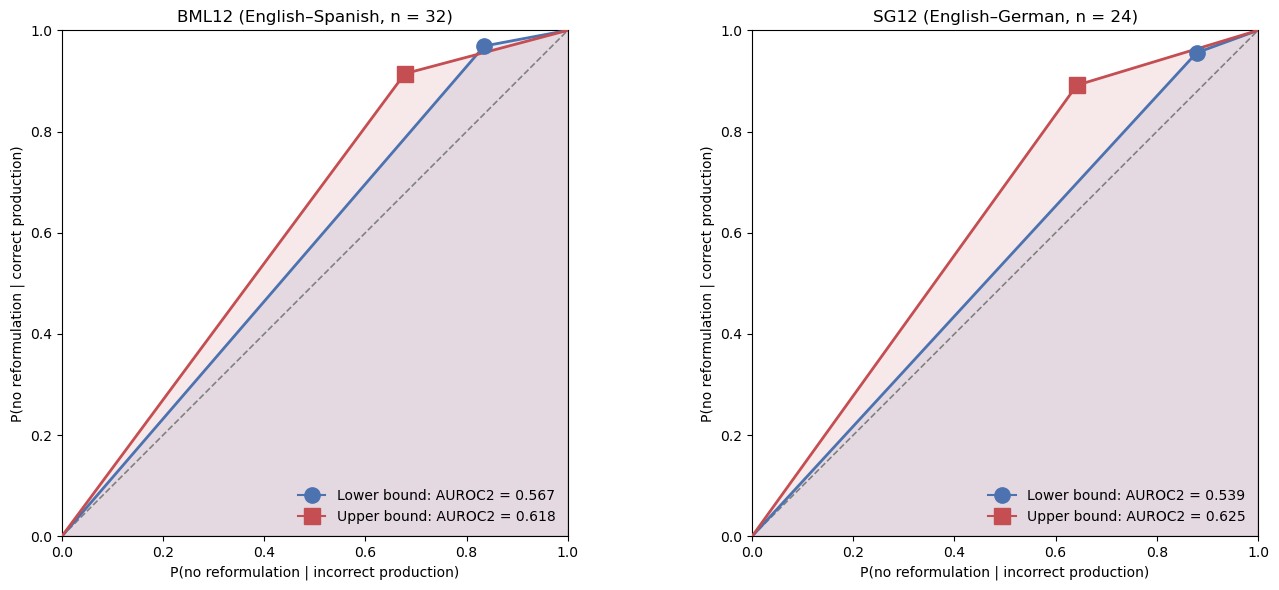

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (label, (path, lang)) in zip(axes, FILES.items()):
    df = _load(path); n = df['Part'].nunique()
    for col, color, mk, name in [('Task_2', BLUE, 'o', 'Lower'),
                                 ('Task_2_Upper', RED, 's', 'Upper')]:
        Fx, Hy = mean_operating_point(df, col)          # mean per-participant point
        auc = per_participant_auc(df, col).mean()        # equals area at that point
        ax.fill([0, Fx, 1, 1], [0, Hy, 1, 0], color=color, alpha=0.12, zorder=1)
        ax.plot([0, Fx, 1], [0, Hy, 1], color=color, lw=2, zorder=3)
        ax.plot(Fx, Hy, marker=mk, color=color, ms=11, zorder=4,
                label=f'{name} bound: AUROC2 = {auc:.3f}')
    ax.plot([0, 1], [0, 1], '--', color='0.5', lw=1.2, zorder=2)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
    ax.set_xlabel('P(no reformulation | incorrect production)')
    ax.set_ylabel('P(no reformulation | correct production)')
    ax.set_title(f'{label} ({lang}, n = {n})')
    ax.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.savefig('fig1_type2_roc.png', dpi=300, bbox_inches='tight')
plt.show()

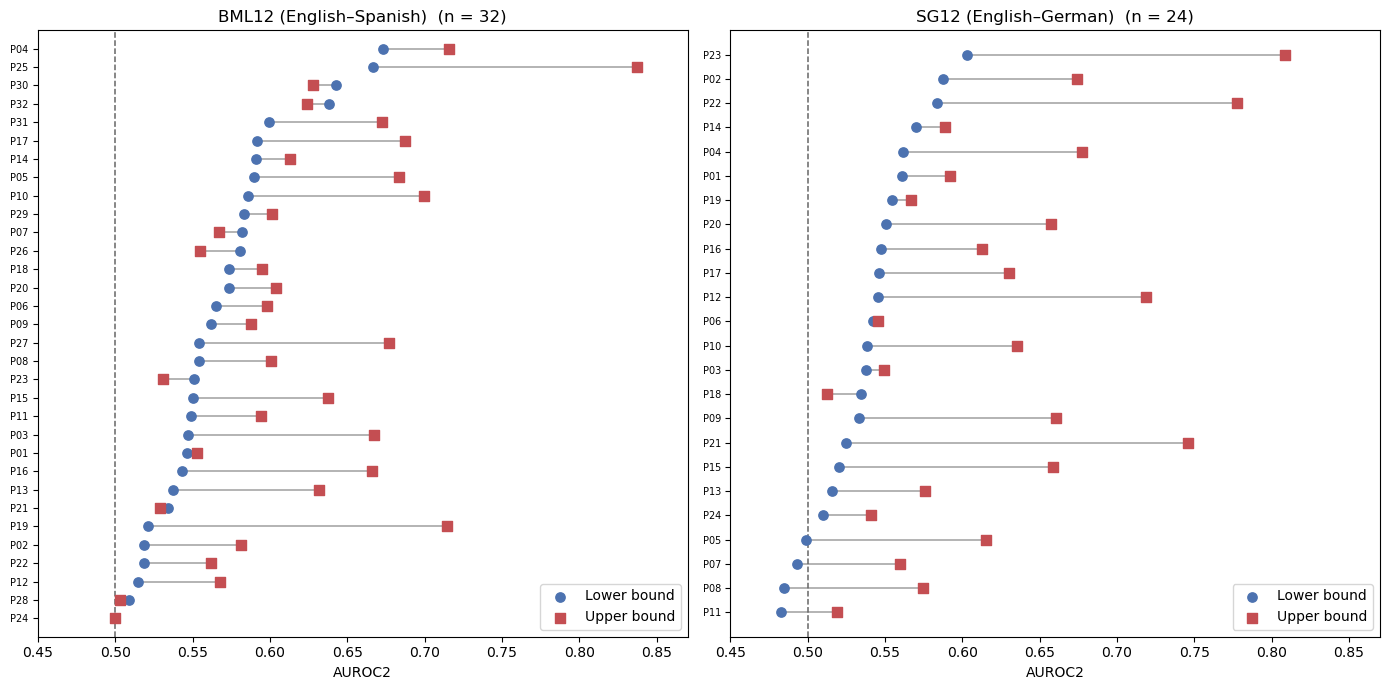

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, (label, (path, lang)) in zip(axes, FILES.items()):
    df = _load(path)
    lo = per_participant_auc(df, 'Task_2')
    up = per_participant_auc(df, 'Task_2_Upper')
    order = lo.sort_values().index     # ascending
    y = np.arange(len(order))
    for yi, p in zip(y, order):
        ax.plot([lo[p], up[p]], [yi, yi], color='0.7', lw=1.4, zorder=1)
    ax.scatter(lo[order], y, color=BLUE, s=45, zorder=3, label='Lower bound')
    ax.scatter(up[order], y, color=RED, marker='s', s=42, zorder=3, label='Upper bound')
    ax.axvline(0.5, ls='--', color='0.4', lw=1.1)
    ax.set_yticks(y); ax.set_yticklabels(order, fontsize=7)
    ax.set_ylim(-1, len(order))
    ax.set_xlim(0.45, 0.87); ax.set_xlabel('AUROC2')
    ax.set_title(f'{label} ({lang})  (n = {df["Part"].nunique()})')
    ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig('fig2_per_participant_auroc2.png', dpi=300, bbox_inches='tight')
plt.show()

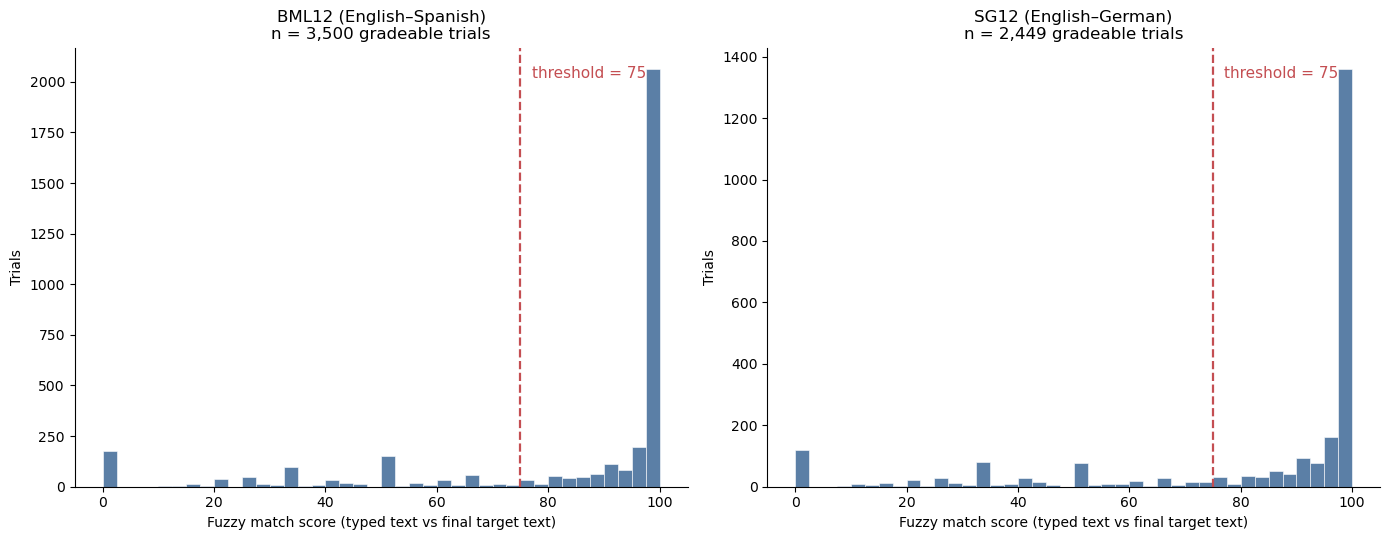

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
bins = np.arange(0, 102.5, 2.5)     # width-2.5 (40 bins)
for ax, (label, (path, lang)) in zip(axes, FILES.items()):
    s = pd.read_csv(path)['Task_1_Score'].dropna()
    ax.hist(s, bins=bins, color='#5B7FA6', edgecolor='white', linewidth=0.4)
    ax.axvline(75, ls='--', color=RED, lw=1.6)
    ax.text(77, ax.get_ylim()[1] * 0.93, 'threshold = 75', color=RED, fontsize=11)
    ax.set_xlabel('Fuzzy match score (typed text vs final target text)')
    ax.set_ylabel('Trials')
    ax.set_title(f'{label} ({lang})\nn = {len(s):,} gradeable trials')
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig3_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

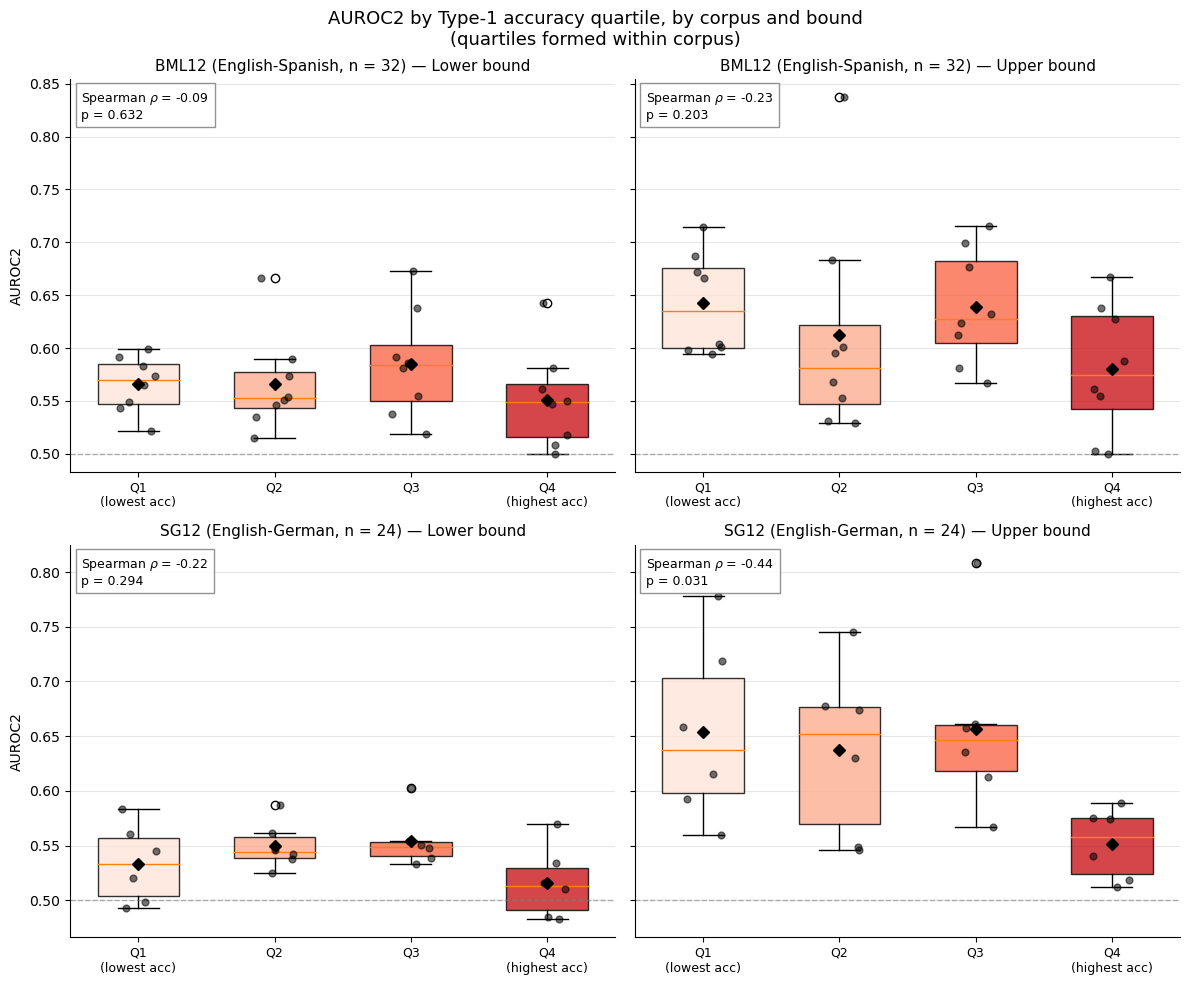

  AUROC2 by Type-1 accuracy quartile (within corpus)

BML12 (English-Spanish)
                   n_participants  mean_accuracy  mean_n_unstable  AUROC2_lower  AUROC2_upper
acc_quartile                                                                                 
Q1\n(lowest acc)                8          0.678           37.500         0.566         0.642
Q2                              8          0.762           25.375         0.566         0.612
Q3                              8          0.798           22.125         0.585         0.639
Q4\n(highest acc)               8          0.873           14.375         0.551         0.580
  accuracy vs AUROC2 (lower): rho = -0.088, p = 0.632
  accuracy vs AUROC2 (upper): rho = -0.231, p = 0.203

SG12 (English-German)
                   n_participants  mean_accuracy  mean_n_unstable  AUROC2_lower  AUROC2_upper
acc_quartile                                                                                 
Q1\n(lowest acc)                6      

In [71]:
#AUROC2 by Task 1 accuracy quartile, each corpus separately

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

TRIAL_FILES = [('BML12', 'BML12_2bin_trials.csv', 'English-Spanish'),
               ('SG12',  'SG12_2bin_trials.csv',  'English-German')]
BOUNDS = [('Task_2', 'Lower bound'), ('Task_2_Upper', 'Upper bound')]

QUARTILE_LABELS = ['Q1\n(lowest acc)', 'Q2', 'Q3', 'Q4\n(highest acc)']
QUARTILE_COLOURS = ['#fee5d9', '#fcae91', '#fb6a4a', '#cb181d']


def participant_table(path):
    """One row per participant: Task 1 accuracy and AUROC2 under each bound."""
    d = pd.read_csv(path).dropna(subset=['Task_1']).copy()
    d['Task_1'] = d['Task_1'].astype(int)
    rows = []
    for part, g in d.groupby('Part'):
        two_classes = g['Task_1'].nunique() == 2
        rows.append({
            'Part':       part,
            'accuracy':   g['Task_1'].mean(),
            'n_trials':   len(g),
            'n_unstable': int((g['Task_1'] == 0).sum()),
            **{col: (roc_auc_score(g['Task_1'], g[col]) if two_classes else np.nan)
               for col, _ in BOUNDS},
        })
    out = pd.DataFrame(rows)
    # Quartiles formed within this corpus only
    out['acc_quartile'] = pd.qcut(out['accuracy'], q=4, labels=QUARTILE_LABELS)
    return out


tables = {label: participant_table(path) for label, path, _ in TRIAL_FILES}

# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey='row')
rng = np.random.default_rng(0)

for row, (label, path, lang) in enumerate(TRIAL_FILES):
    tbl = tables[label]
    for col_i, (col, bound_label) in enumerate(BOUNDS):
        ax = axes[row, col_i]
        data_by_q = [tbl.loc[tbl['acc_quartile'] == q, col].dropna().values
                     for q in QUARTILE_LABELS]

        bp = ax.boxplot(data_by_q, positions=[1, 2, 3, 4], widths=0.6,
                        patch_artist=True, showmeans=True,
                        meanprops={'marker': 'D', 'markerfacecolor': 'black',
                                   'markeredgecolor': 'black', 'markersize': 6})
        for patch, c in zip(bp['boxes'], QUARTILE_COLOURS):
            patch.set_facecolor(c)
            patch.set_alpha(0.8)

        for pos, dat in zip([1, 2, 3, 4], data_by_q):
            jitter = rng.uniform(-0.15, 0.15, size=len(dat))
            ax.scatter(np.full(len(dat), pos) + jitter, dat,
                       s=24, alpha=0.55, color='black', zorder=3)

        ax.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.6)
        ax.set_xticks([1, 2, 3, 4])
        ax.set_xticklabels(QUARTILE_LABELS, fontsize=9)
        ax.set_title(f"{label} ({lang}, n = {len(tbl)}) — {bound_label}", fontsize=11)
        ax.grid(axis='y', alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)
        if col_i == 0:
            ax.set_ylabel('AUROC2')

        # Spearman on the underlying continuous accuracy, within this corpus
        sub = tbl.dropna(subset=[col])
        rho, p = spearmanr(sub['accuracy'], sub[col])
        ax.text(0.02, 0.97, f"Spearman $\\rho$ = {rho:+.2f}\np = {p:.3f}",
                transform=ax.transAxes, fontsize=9, va='top',
                bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85))

fig.suptitle('AUROC2 by Type-1 accuracy quartile, by corpus and bound\n'
             '(quartiles formed within corpus)', fontsize=13)
plt.tight_layout()
plt.savefig('fig4_quartile_dissociation.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
summary_rows = []
print('=' * 82)
print('  AUROC2 by Type-1 accuracy quartile (within corpus)')
print('=' * 82)
for label, path, lang in TRIAL_FILES:
    tbl = tables[label]
    agg = (tbl.groupby('acc_quartile', observed=True)
              .agg(n_participants=('Part', 'size'),
                   mean_accuracy=('accuracy', 'mean'),
                   mean_n_unstable=('n_unstable', 'mean'),
                   AUROC2_lower=('Task_2', 'mean'),
                   AUROC2_upper=('Task_2_Upper', 'mean'))
              .round(3))
    print(f"\n{label} ({lang})")
    print(agg.to_string())
    for col, bound_label in BOUNDS:
        sub = tbl.dropna(subset=[col])
        rho, p = spearmanr(sub['accuracy'], sub[col])
        print(f"  accuracy vs AUROC2 ({bound_label.split()[0].lower()}): "
              f"rho = {rho:+.3f}, p = {p:.3f}")
    agg = agg.reset_index()
    agg.insert(0, 'study', label)
    summary_rows.append(agg)

pd.concat(summary_rows, ignore_index=True).to_csv('quartile_auroc2_by_corpus.csv', index=False)
print("\nSaved fig4_quartile_dissociation.png and quartile_auroc2_by_corpus.csv")

In [72]:
# H2 and F2 by Task 1 accuracy quartile within corpus

import pandas as pd
import numpy as np

TRIAL_FILES = [('BML12', 'BML12_2bin_trials.csv'),
               ('SG12',  'SG12_2bin_trials.csv')]
QUARTILE_LABELS = ['Q1', 'Q2', 'Q3', 'Q4']


def participant_hf(path):
    """One row per participant: accuracy, quartile, and H2/F2 under each bound."""
    d = pd.read_csv(path).dropna(subset=['Task_1']).copy()
    d['Task_1'] = d['Task_1'].astype(int)
    rows = []
    for part, g in d.groupby('Part'):
        correct = g[g['Task_1'] == 1]
        incorrect = g[g['Task_1'] == 0]
        # H2/F2 undefined if participant has no correct/no incorrect trials
        rows.append({
            'Part': part,
            'accuracy': g['Task_1'].mean(),
            'H2':    (correct['Task_2'] == 2).mean() if len(correct) else np.nan,
            'H2_up': (correct['Task_2_Upper'] == 2).mean() if len(correct) else np.nan,
            'F2_lo': (incorrect['Task_2'] == 2).mean() if len(incorrect) else np.nan,
            'F2_up': (incorrect['Task_2_Upper'] == 2).mean() if len(incorrect) else np.nan,
        })
    out = pd.DataFrame(rows)
    out['acc_quartile'] = pd.qcut(out['accuracy'], 4, labels=QUARTILE_LABELS)
    return out


for label, path in TRIAL_FILES:
    t = participant_hf(path)
    print('=' * 78)
    print(label, '(per-participant means within quartile)')
    print(f"{'quartile':<10}{'n_part':>7}{'mean_acc':>10}"
          f"{'H2':>8}{'F2_lo':>8}{'AUC_lo':>9}{'F2_up':>8}{'AUC_up':>9}")
    for qlab in QUARTILE_LABELS:
        sub = t[t['acc_quartile'] == qlab]
        H2 = sub['H2'].mean(); H2_up = sub['H2_up'].mean()
        F2_lo = sub['F2_lo'].mean(); F2_up = sub['F2_up'].mean()
        auc_lo = 0.5 * (H2 + (1 - F2_lo))
        auc_up = 0.5 * (H2_up + (1 - F2_up))
        print(f"{qlab:<10}{len(sub):>7}{sub['accuracy'].mean():>10.3f}"
              f"{H2:>8.3f}{F2_lo:>8.3f}{auc_lo:>9.3f}{F2_up:>8.3f}{auc_up:>9.3f}")
    q1 = t[t['acc_quartile'] == 'Q1']; q4 = t[t['acc_quartile'] == 'Q4']
    print(f"  lower bound Q1->Q4:  "
          f"H2 {q1['H2'].mean():.3f}->{q4['H2'].mean():.3f}   "
          f"F2 {q1['F2_lo'].mean():.3f}->{q4['F2_lo'].mean():.3f}")

BML12 (per-participant means within quartile)
quartile   n_part  mean_acc      H2   F2_lo   AUC_lo   F2_up   AUC_up
Q1              8     0.678   0.969   0.838    0.566   0.594    0.642
Q2              8     0.762   0.973   0.840    0.566   0.693    0.612
Q3              8     0.798   0.959   0.789    0.585   0.627    0.639
Q4              8     0.873   0.974   0.872    0.551   0.797    0.580
  lower bound Q1->Q4:  H2 0.969->0.974   F2 0.838->0.872
SG12 (per-participant means within quartile)
quartile   n_part  mean_acc      H2   F2_lo   AUC_lo   F2_up   AUC_up
Q1              6     0.653   0.950   0.883    0.534   0.525    0.654
Q2              6     0.773   0.949   0.849    0.550   0.621    0.637
Q3              6     0.821   0.968   0.860    0.554   0.612    0.657
Q4              6     0.876   0.956   0.923    0.516   0.810    0.552
  lower bound Q1->Q4:  H2 0.950->0.956   F2 0.883->0.923


In [73]:
# Between-participant AUROC2 variance

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

for label, path in [('BML12', 'BML12_2bin_trials.csv'),
                    ('SG12',  'SG12_2bin_trials.csv')]:
    d = pd.read_csv(path).dropna(subset=['Task_1']).copy()
    d['Task_1'] = d['Task_1'].astype(int)

    rows = []
    for part, g in d.groupby('Part'):
        if g['Task_1'].nunique() < 2:
            continue
        correct = g[g['Task_1'] == 1]
        incorrect = g[g['Task_1'] == 0]
        H2 = (correct['Task_2'] == 2).mean()
        F2 = (incorrect['Task_2'] == 2).mean()
        rows.append({
            'Part': part,
            'AUROC2': roc_auc_score(g['Task_1'], g['Task_2']),
            'H2': H2,
            'F2': F2,
            'P_Bin1_unstable': 1 - F2,     # error reformulation rate
            'P_Bin1_stable':   1 - H2,     # correct reformulation rate
            'n_err': len(incorrect),
        })
    r = pd.DataFrame(rows)

    print('=' * 66)
    print(f'{label}  (n = {len(r)} participants)')

    # variance of each component across participants
    print(f'  H2  across participants: mean {r.H2.mean():.3f}  SD {r.H2.std(ddof=1):.3f}  '
          f'range {r.H2.min():.3f}-{r.H2.max():.3f}')
    print(f'  F2  across participants: mean {r.F2.mean():.3f}  SD {r.F2.std(ddof=1):.3f}  '
          f'range {r.F2.min():.3f}-{r.F2.max():.3f}')

    # how much AUROC2 variance each term explains
    for col, name in [('P_Bin1_unstable', 'P(Bin 1 | unstable) = 1-F2'),
                      ('P_Bin1_stable',   'P(Bin 1 | stable)   = 1-H2')]:
        rr = r['AUROC2'].corr(r[col])
        print(f'  AUROC2 ~ {name}: r = {rr:+.3f},  R2 = {rr**2:.3f}  '
              f'({rr**2*100:.0f}% of between-participant variance)')

    # both together
    X = np.column_stack([r.P_Bin1_unstable, r.P_Bin1_stable, np.ones(len(r))])
    beta, *_ = np.linalg.lstsq(X, r.AUROC2, rcond=None)
    pred = X @ beta
    r2_both = 1 - ((r.AUROC2 - pred) ** 2).sum() / ((r.AUROC2 - r.AUROC2.mean()) ** 2).sum()
    print(f'  both terms together: R2 = {r2_both:.3f}')

BML12  (n = 32 participants)
  H2  across participants: mean 0.969  SD 0.020  range 0.920-1.000
  F2  across participants: mean 0.835  SD 0.087  range 0.615-1.000
  AUROC2 ~ P(Bin 1 | unstable) = 1-F2: r = +0.974,  R2 = 0.948  (95% of between-participant variance)
  AUROC2 ~ P(Bin 1 | stable)   = 1-H2: r = -0.103,  R2 = 0.011  (1% of between-participant variance)
  both terms together: R2 = 1.000
SG12  (n = 24 participants)
  H2  across participants: mean 0.956  SD 0.020  range 0.909-0.978
  F2  across participants: mean 0.879  SD 0.065  range 0.769-1.000
  AUROC2 ~ P(Bin 1 | unstable) = 1-F2: r = +0.953,  R2 = 0.908  (91% of between-participant variance)
  AUROC2 ~ P(Bin 1 | stable)   = 1-H2: r = -0.059,  R2 = 0.004  (0% of between-participant variance)
  both terms together: R2 = 1.000


  Sensitivity of AUROC2 to mechanical confounding (t = mechanically produced share)
 study       bound  breakdown_mean  breakdown_ci_lower  t=0.0  t=0.2  t=0.5  t=0.8  t=1.0
 BML12 Lower bound           0.680               0.625  0.567  0.544  0.519  0.492  0.462
 BML12 Upper bound           0.690               0.635  0.618  0.581  0.538  0.486  0.417
  SG12 Lower bound           0.525               0.440  0.539  0.521  0.502  0.482  0.460
  SG12 Upper bound           0.685               0.605  0.625  0.585  0.540  0.484  0.402
Pooled Lower bound           0.625               0.575  0.555  0.534  0.512  0.487  0.461
Pooled Upper bound           0.690               0.640  0.621  0.583  0.538  0.485  0.411

Breakdown points (t at which the estimate reaches 0.5):
  BML12   Lower bound  group mean: t = 0.680   |  lower CI bound: t = 0.625
  BML12   Upper bound  group mean: t = 0.690   |  lower CI bound: t = 0.635
  SG12    Lower bound  group mean: t = 0.525   |  lower CI bound: t = 0.440
 

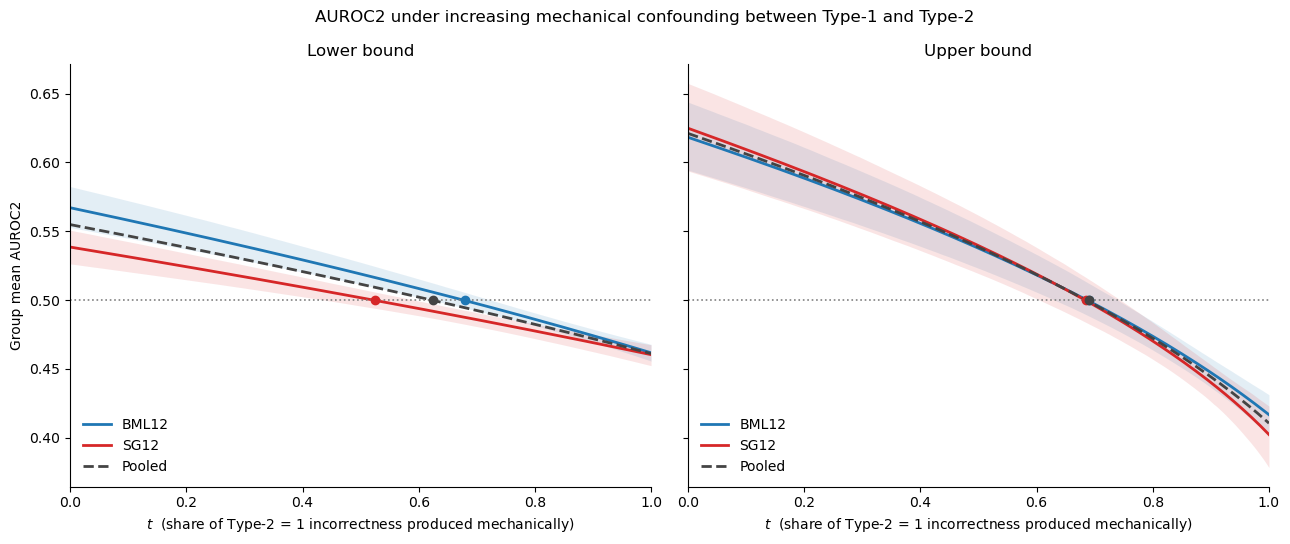


Saved fig5_mechanical_sensitivity.png and mechanical_sensitivity.csv


In [74]:
# Sensitivity of AUROC2 to mechanical confounding between the tasks

# Parameter t = the proportion of (incorrect reformulated) trials that
# are wrong as a mechanical consequence of the reformulation and
# would otherwise have been correct. Those trials are reassigned to the
# stable row, keeping them in Bin 1, and AUROC2 is recomputed.
#
#   t = 0  -> no mechanical contribution
#   t = 1  -> every such trial is mechanically produced
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TRIAL_FILES = [('BML12', 'BML12_2bin_trials.csv'), ('SG12', 'SG12_2bin_trials.csv')]
BOUNDS = [('Task_2', 'Lower bound'), ('Task_2_Upper', 'Upper bound')]
T_GRID = np.linspace(0, 1, 201)
N_BOOT = 10000
SEED = 0


def participant_cells(path, col):
    """Per-participant 2x2 counts: (incorrect/Bin1, incorrect/Bin2, correct/Bin1, correct/Bin2)."""
    d = pd.read_csv(path).dropna(subset=['Task_1']).copy()
    d['Task_1'] = d['Task_1'].astype(int)
    out = []
    for _, g in d.groupby('Part'):
        out.append((
            int(((g['Task_1'] == 0) & (g[col] == 1)).sum()),
            int(((g['Task_1'] == 0) & (g[col] == 2)).sum()),
            int(((g['Task_1'] == 1) & (g[col] == 1)).sum()),
            int(((g['Task_1'] == 1) & (g[col] == 2)).sum()),
        ))
    return np.array(out, dtype=float)


def auroc2_at_t(cells, t):
    """AUROC2 per participant after reassigning a fraction t of the incorrect/Bin1 cell."""
    n01, n02, n11, n12 = cells.T
    unstable = n02 + (1 - t) * n01
    stable   = n12 + n11 + t * n01
    with np.errstate(invalid='ignore', divide='ignore'):
        F2 = np.where(unstable > 0, n02 / unstable, np.nan)
        H2 = np.where(stable   > 0, n12 / stable,   np.nan)
    return 0.5 * (H2 + 1 - F2)


def boot_ci(vals, n_boot=N_BOOT, seed=SEED):
    v = np.asarray(vals, dtype=float)
    v = v[~np.isnan(v)]
    rng = np.random.default_rng(seed)
    b = np.array([v[rng.integers(0, len(v), len(v))].mean() for _ in range(n_boot)])
    return v.mean(), np.percentile(b, 2.5), np.percentile(b, 97.5)


def breakdown_point(curve, grid, level=0.5):
    """Smallest t at which the curve falls to or below `level`."""
    hit = np.where(curve <= level)[0]
    return grid[hit[0]] if len(hit) else np.nan


# ------------------------------------------------------------------
# Sweep
results, rows = {}, []
for study, path in TRIAL_FILES:
    for col, bound_label in BOUNDS:
        cells = participant_cells(path, col)
        means = np.array([np.nanmean(auroc2_at_t(cells, t)) for t in T_GRID])
        los   = np.array([boot_ci(auroc2_at_t(cells, t))[1] for t in T_GRID])
        key = (study, bound_label)
        results[key] = {'cells': cells, 'mean': means, 'lo': los}
        rows.append({
            'study': study, 'bound': bound_label,
            'breakdown_mean': breakdown_point(means, T_GRID),
            'breakdown_ci_lower': breakdown_point(los, T_GRID),
            **{f't={t:.1f}': np.nanmean(auroc2_at_t(cells, t))
               for t in [0, 0.25, 0.5, 0.75, 1.0]},
        })

# Pooled across corpora by bound
for col, bound_label in BOUNDS:
    cells = np.vstack([participant_cells(p, col) for _, p in TRIAL_FILES])
    means = np.array([np.nanmean(auroc2_at_t(cells, t)) for t in T_GRID])
    los   = np.array([boot_ci(auroc2_at_t(cells, t))[1] for t in T_GRID])
    results[('Pooled', bound_label)] = {'cells': cells, 'mean': means, 'lo': los}
    rows.append({
        'study': 'Pooled', 'bound': bound_label,
        'breakdown_mean': breakdown_point(means, T_GRID),
        'breakdown_ci_lower': breakdown_point(los, T_GRID),
        **{f't={t:.1f}': np.nanmean(auroc2_at_t(cells, t))
           for t in [0, 0.25, 0.5, 0.75, 1.0]},
    })

sens = pd.DataFrame(rows)
print('=' * 96)
print('  Sensitivity of AUROC2 to mechanical confounding (t = mechanically produced share)')
print('=' * 96)
print(sens.round(3).to_string(index=False))
sens.to_csv('mechanical_sensitivity.csv', index=False)

print('\nBreakdown points (t at which the estimate reaches 0.5):')
for _, r in sens.iterrows():
    print(f"  {r['study']:<7} {r['bound']:<12} group mean: t = {r['breakdown_mean']:.3f}"
          f"   |  lower CI bound: t = {r['breakdown_ci_lower']:.3f}")

# ------------------------------------------------------------------
# Figure
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
colours = {'BML12': '#1f77b4', 'SG12': '#d62728', 'Pooled': '#444444'}

for ax, (col, bound_label) in zip(axes, BOUNDS):
    for study in ['BML12', 'SG12', 'Pooled']:
        r = results[(study, bound_label)]
        style = '-' if study != 'Pooled' else '--'
        ax.plot(T_GRID, r['mean'], style, color=colours[study], lw=2, label=study)
        if study != 'Pooled':
            ax.fill_between(T_GRID, r['lo'],
                            [boot_ci(auroc2_at_t(r['cells'], t))[2] for t in T_GRID],
                            color=colours[study], alpha=0.12, lw=0)
        bp = breakdown_point(r['mean'], T_GRID)
        if not np.isnan(bp):
            ax.plot([bp], [0.5], marker='o', ms=6, color=colours[study], zorder=5)
    ax.axhline(0.5, color='gray', ls=':', lw=1.2)
    ax.set_xlabel('$t$  (share of Type-2 = 1 incorrectness produced mechanically)')
    ax.set_title(bound_label)
    ax.set_xlim(0, 1)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, loc='lower left')

axes[0].set_ylabel('Group mean AUROC2')
fig.suptitle('AUROC2 under increasing mechanical confounding between Type-1 and Type-2',
             fontsize=12)
plt.tight_layout()
plt.savefig('fig5_mechanical_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()
print('\nSaved fig5_mechanical_sensitivity.png and mechanical_sensitivity.csv')

In [75]:
# Self-repair leak diagnostic (lower bound only)

#     - If a deletion's length exceeds the typed at that point, it goes
#       into text typed before this unit began -> reaches preceding
#       production.
#     - If it is smaller, it stays within this unit's own typing -> confined.
#   A deletion whose length EQUALS `typed` lands exactly on the boundary and is ambiguous:
#     STRICT    : only > reaches prev
#     INCLUSIVE : >= reaches prev
import pandas as pd
import numpy as np
import re
from sklearn.metrics import roc_auc_score

TOKEN = re.compile(r'(\[[^\]]*\])')


def reaches_prev(edit, boundary_reaches):
    """Does any deletion in this edit string reach into the preceding unit"""
    typed = 0
    for tok in TOKEN.split(str(edit)):
        if tok.startswith('[') and tok.endswith(']'):
            dl = len(tok) - 2                      # chars deleted
            reach = (dl >= typed) if boundary_reaches else (dl > typed)
            if reach:
                return True
            typed = max(0, typed - dl)             # deletion consumes typed buffer
        else:
            typed += len(tok)                      # ordinary typing adds to buffer
    return False


def auroc2(df, col):
    g = df.dropna(subset=['Task_1']).copy()
    g['Task_1'] = g['Task_1'].astype(int)
    if g['Task_1'].nunique() < 2:
        return np.nan
    return roc_auc_score(g['Task_1'], g[col])


def group_auroc2(df, col):
    """Per-participant mean AUROC2."""
    g = df.dropna(subset=['Task_1']).copy()
    g['Task_1'] = g['Task_1'].astype(int)
    vals = [roc_auc_score(x['Task_1'], x[col])
            for _, x in g.groupby('Part') if x['Task_1'].nunique() == 2]
    return float(np.mean(vals))


for label, path in [('BML12', 'BML12_2bin_trials.csv'),
                    ('SG12',  'SG12_2bin_trials.csv')]:
    d = pd.read_csv(path).dropna(subset=['Task_1']).copy()
    d['Task_1'] = d['Task_1'].astype(int)
    bin1 = d[d['Task_2'] == 1].copy()

    print('=' * 70)
    print(label)

    # leak rate under each criterion
    for crit_name, boundary in [('strict', False), ('inclusive', True)]:
        reach = bin1['Next_PU_Edit'].apply(lambda e: reaches_prev(e, boundary))
        confined = (~reach).mean() * 100
        print(f'  {crit_name:9}: confined (leak) = {confined:5.1f}%   '
              f'reaches prev = {reach.mean()*100:5.1f}%')

    # leak split by Task 1 (using strict, the conservative reading)
    reach_strict = bin1['Next_PU_Edit'].apply(lambda e: reaches_prev(e, False))
    bin1 = bin1.assign(reaches=reach_strict)
    inc = bin1[bin1['Task_1'] == 0]; cor = bin1[bin1['Task_1'] == 1]
    print(f'  reaches prev among INCORRECT Bin 1 (false-alarm cell): '
          f'{inc["reaches"].mean()*100:.1f}%')
    print(f'  reaches prev among CORRECT   Bin 1: '
          f'{cor["reaches"].mean()*100:.1f}%')

    # baseline AUROC2 (per-participant mean) for reference
    base = group_auroc2(d, 'Task_2')
    print(f'  baseline group AUROC2 (lower)      = {base:.3f}')

    # recode confined Bin-1 trials to Bin 2 and recompute, each criterion
    for crit_name, boundary in [('strict', False), ('inclusive', True)]:
        d2 = d.copy()
        conf = (d2['Task_2'] == 1) & (~d2['Next_PU_Edit'].apply(
            lambda e: reaches_prev(e, boundary)))
        d2.loc[conf, 'Task_2'] = 2                # confined -> not a reformulation
        rec = group_auroc2(d2, 'Task_2')
        print(f'  recoded AUROC2 ({crit_name:9}) = {rec:.3f}   '
              f'(Δ {rec-base:+.3f}, {conf.sum()} trials recoded)')

BML12
  strict   : confined (leak) =  18.4%   reaches prev =  81.6%
  inclusive: confined (leak) =   9.7%   reaches prev =  90.3%
  reaches prev among INCORRECT Bin 1 (false-alarm cell): 95.5%
  reaches prev among CORRECT   Bin 1: 60.0%
  baseline group AUROC2 (lower)      = 0.567
  recoded AUROC2 (strict   ) = 0.569   (Δ +0.002, 40 trials recoded)
  recoded AUROC2 (inclusive) = 0.567   (Δ +0.000, 21 trials recoded)
SG12
  strict   : confined (leak) =  21.9%   reaches prev =  78.1%
  inclusive: confined (leak) =  15.5%   reaches prev =  84.5%
  reaches prev among INCORRECT Bin 1 (false-alarm cell): 89.2%
  reaches prev among CORRECT   Bin 1: 67.9%
  baseline group AUROC2 (lower)      = 0.539
  recoded AUROC2 (strict   ) = 0.539   (Δ +0.001, 34 trials recoded)
  recoded AUROC2 (inclusive) = 0.537   (Δ -0.002, 24 trials recoded)
